# Machine Learning–Based Prediction of Capital Bikeshare Usage in Washington, D.C.


## Table of Content

- [1. Introduction](#1-introduction)
- [2. Methodology](#2-methodology)
  - [2.1 Data Preprocessing](#21-data-preprocessing)
  - [2.2 Data Analysis](#22-data-analysis)
- [3. Modelling and Optimization](#3-modelling-and-Optimization)
  - [3.1 Linear Regression](#31-Linear-Regression)
  - [3.2 Ridge Regression](#32-Ridge-Regression)
  - [3.3 LASSO Regression](#33-LASSO-Regression)
  - [3.4 Random Forest Regression](#34-Random-Forest-Regression)
- [4. Evaluation](#4-evaluation)
- [5. Conclusion and Future Work](#5-conclusion-and-future-work)
- [6. Sources](#6-Sources)

## 1. Introduction



In recent years, bike‑sharing systems have become an increasingly popular, eco‑friendly urban mobility solution. By allowing users to pick up and drop off bicycles at automated stations throughout a city, these systems help reduce traffic congestion, lower carbon emissions, and promote healthy lifestyles.   Beyond their real‑world applications, the unique properties of data generated by bike‑sharing systems also make them highly valuable for research. Effectively managing a bike‑sharing network requires accurate demand forecasting. Operators need to know how many bikes will be rented on any given day in order to redistribute fleets, schedule maintenance and ensure availability.

To accomplish this, this project will focus on modeling and prediction of the daily rental counts for the Capital Bikeshare system in Washington, D.C. We use the publicly available “day.csv” dataset [1], which contains 731 daily observations spanning 2011–2012. Each record includes both environmental factors (e.g., temperature, humidity, wind speed) and temporal variables (season, month, weekday, holiday). Our primary goal is to build a regression model that can capture the relationships between these features and the total number of rented bikes (`total_count`), thereby enabling reliable short‑term demand forecasts.


Specifically, the project will proceed in four main stages:

1. **Data Preprocessing & Exploratory Analysis**  
   - Clean and validate the dataset (missing values, data types).    
   - Conduct exploratory data analysis (correlations, distributions, visual diagnostics) to understand variable behavior and interdependencies.  

2. **Model Development**  
   - Train a series of regression models:  
     - **Ordinary Least Squares**  
     - **Ridge Regression** 
     - **Lasso Regression**   
     - **Random Forest Regressor** 
   - Use scikit‑learn pipelines with appropriate preprocessing steps (One‑Hot encoding for categorical variables, scaling for numerical inputs). 
   - Optimize hyperparameters via k‑fold cross‑validation and grid search.

3. **Model Evaluation & Interpretation**   
   - Compare models using RMSE and R² on held‑out test data.  
   - Analyze feature importances and coefficient magnitudes to identify the strongest predictors of bike demand.  

4. **Conclusions & Future Directions**  
   - Summarize key findings and model performance.  
   - Discuss limitations and suggest avenues for improvement. 

In [1]:
# Import Libraries
import os
import sys
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.stats.outliers_influence import variance_inflation_factor
sns.set_style("ticks")


## 2. Methodology

This chapter outlines the systematic approach taken to analyze the dataset and develop a foundation for the flowing predictive modeling. It begins with a detailed description of the dataset used for this project, followed by an initial exploratory data analysis to understand its fundamental characteristics. This lays the groundwork for subsequent preprocessing and the application of machine learning algorithms.

As already mentioned the foundation of this project is the Bike Sharing Dataset, specifically the `day.csv` file, which contains 731 daily observations recorded over two years (2011-2012) for the Capital Bikeshare system in Washington D.C. The dataset includes a rich set of features that provide seasonal, temporal, and weather-related context, such as the season, month, day of the week, and weather situation (e.g., clear, misty, or light snow/rain). All numerical features, such as temperature, humidity, and wind speed, have been normalized. A detailed description of each variable is provided in **Table 1** below

**Table 1:** Description of dataset variables.

| Variable      | Description                                                                       |
|---------------|-----------------------------------------------------------------------------------|
| `dteday`      | Date of the observation                                                           |
| `season`      | Season (1: Winter, 2: Spring, 3: Summer, 4: Fall)                                 |
| `year`        | Year (0: 2011, 1: 2012)                                                           |
| `month`       | Month (1 to 12)                                                                   |
| `holiday`     | Binary flag indicating if the day is a holiday (1) or not (0)                     |
| `weekday`     | Day of the week (0: Sunday, 1: Monday, ..., 6: Saturday)                         |
| `workingday`  | Binary flag; 1 if the day is neither weekend nor holiday, otherwise 0            |
| `weathersit`  | Weather situation (1: Clear/Sunny, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Thunderstorm) |
| `temperature` | Normalized temperature in Celsius                                                 |
| `atemp`       | Normalized “feels like” temperature in Celsius                                    |
| `hum`         | Normalized humidity                                                               |
| `windspeed`   | Normalized wind speed                                                             |
| `casual`      | Count of unregistered (casual) users                                              |
| `registered`  | Count of registered users                                                         |
| `total_count` | Total number of bikes rented that day (`casual` + `registered`)                   |



For a better readability we rename the variables as in **table1**.

In [2]:
day_bike = pd.read_csv('day.csv')

# Renaming columns for better readability 
day_bike.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count',
    'dteday': 'date',

}, inplace=True)
# Display the first few rows of the modified DataFrame
day_bike.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### 2.1 Data Preprocessing

To begin the analysis, a comprehensive overview of the dataset was generated using a custom function, `enhanced_data_overview`.

In [3]:
def enhanced_data_overview(df, head_rows=5):
    """
    Display an extended overview of the DataFrame:
    - Missing values (count + percentage)
    - Duplicate rows
    - Data types
    - Number of unique values per column
    - Head (first rows)
    - Descriptive statistics for numeric features
    - Descriptive statistics for categorical features
    """

    
    # 3. Missing Values
    display(Markdown("#### **Table 2:** Missing Values"))
    missing = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().mean() * 100).round(2)
    })
    display(missing)
    
    # 4. Duplicate Rows
    display(Markdown("#### Duplicate Rows:"))
    dup_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {dup_count}\n")
    
    # 5. Data Types
    display(Markdown("#### **Table 3:** Data Types"))
    display(pd.DataFrame(df.dtypes, columns=['Dtype']))
    
    # 6. Unique Values Count
    display(Markdown("#### **Table 4:** Unique Values per Column"))
    unique_counts = pd.DataFrame({
        'Unique Count': df.nunique()
        
    })
    display(unique_counts)

    # 7. Head (first rows)
    display(Markdown("#### **Table 5:** Head (First Rows)"))
    display(df.head(head_rows))

    #8. Descriptive Statistics
    display(Markdown("#### **Table 6:** Descriptive Statistics"))
    display(df.describe(include='all'))

# Call the function to display the overview
enhanced_data_overview(day_bike, head_rows=5)

#### **Table 2:** Missing Values

,Missing Count,Missing %
instant,0,0.0
date,0,0.0
season,0,0.0
year,0,0.0
month,0,0.0
holiday,0,0.0
weekday,0,0.0
workingday,0,0.0
weathersit,0,0.0
temperature,0,0.0


#### Duplicate Rows:

Number of duplicate rows: 0



#### **Table 3:** Data Types

...

,Unique Count
instant,731
date,731
season,4
year,2
month,12
holiday,2
weekday,7
workingday,2
weathersit,3
temperature,499


#### **Table 5:** Head (First Rows)

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### **Table 6:** Descriptive Statistics

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


A key finding from this preliminary check is the excellent quality of the data, there are no missing values across any of the columns and no duplicate rows were found. This cleanliness simplifies the data preprocessing phase, as no imputation or removal of records is necessary.

An examination of the data types reveals a mix of numerical and categorical data. Most columns are stored as integers (`int64`), such as ``season``, `year`, and ``weekday``as well as our target variable ``total_count``. The weather-related features like ``temperature``, ``feeling_temperature``, ``humidity``, and ``windspeed`` are stored as floating-point numbers (float64), reflecting their normalized nature. The ``date`` column, which represents the date, is correctly identified as an object type. Further inspection of the unique value counts for each column (as detailed in **Table 4**) reinforces the distinction between variable types. For instance, variables like season and weathersit have a small, fixed number of unique values, which makes it clear that they should be treated as categorical features in the modeling process.

Finally, because the target variable, ``total_count``, is a continuous numerical value, the dataset is well-suited for a regression task, as the primary goal is to predict this quantitative response based on the available seasonal and weather-related features.

In [4]:

# # Create a dataframe describing each variable
# variables = [
#     "instant", "dteday", "season", "yr", "mnth", "hr", "holiday",
#     "weekday", "workingday", "weathersit", "temp", "atemp", "hum",
#     "windspeed", "casual", "registered", "cnt"
# ]

# descriptions = [
#     "Record index",
#     "Date of the observation",
#     "Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)",
#     "Year (0: 2011, 1: 2012)",
#     "Month (1 to 12)",
#     "Hour (0 to 23) – not available in day.csv",
#     "Indicator if the day is a holiday (1: holiday, 0: not)",
#     "Day of the week (0: Sunday to 6: Saturday)",
#     "Indicator if day is working day (1) or weekend/holiday (0)",
#     "Weather situation (1: Clear/Few clouds, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Snow)",
#     "Normalized temperature in Celsius (divided by 41)",
#     "Normalized feeling temperature in Celsius (divided by 50)",
#     "Normalized humidity (divided by 100)",
#     "Normalized wind speed (divided by 67)",
#     "Count of casual users (leisure)",
#     "Count of registered users (subscribers)",
#     "Total count of bike rentals (casual + registered)"
# ]

# df_variables = pd.DataFrame({
#     "Variable": variables,
#     "Description": descriptions
# })


# df_variables.head(18)



In [5]:
# day_bike = pd.read_csv('day.csv')
# day_bike.head(10)


In [6]:
# day_bike.info()

In [7]:
# Get basic idea of data using describe()
#day_bike.describe()

As our dataset contains both categorical and numerical features, it is essential to distinguish them correctly for effective preprocessing and modeling. Numerical features representing measurable quantities are typically scaled, whereas categorical features denoting distinct groups must first be transformed into numeric form through encoding. To standardize and automate this classification process, a custom function, ``extract_features_categorical``, was implemented.

This function automatically splits the dataset’s columns into two lists: numerical and categorical. It looks at each column’s data type and how many unique values it has. If a column uses a numeric type (for example, int64) but has fewer unique values than a set limit (``cat_th`` = 13), it is treated as categorical. This rule helps catch columns like ``season``, ``month`` and ``weekday`` which use numbers but are not really continuous. Any column with an object type is also treated as categorical. All other columns end up in the numerical list.


In [8]:
def extract_features_categorical(df, cat_th = 13, num_th = 20):
    """
    Extract categorical features from the DataFrame based on thresholds for unique values.
    
    Parameters:
    - df: DataFrame to extract features from
    - cat_th: Threshold for categorical features (default 13)
    - num_th: Threshold for numerical features (default 20)
    
    Returns:
    - cat_cols: List of categorical feature names
    - num_cols: List of numerical feature names
    """
    # 1. Identify 'true' categorical columns
    cat_cols = [col for col in df.columns if df[col].dtype == "O"]

    # 2. Identify numeric columns that should be treated as categorical
    #    because they have fewer than cat_th unique values
    num_but_cat = [
        col for col in df.columns
        if df[col].nunique() < cat_th and df[col].dtypes != "O"
    ]
    # 3. Identify 'categorical but high cardinality' columns
    cat_but_car = [
        col for col in df.columns
        if df[col].nunique() > cat_th and df[col].dtypes == "O"
    ]
    # 4. Combine object-type categorical columns and numeric-but-categorical columns,
    #    then exclude any high-cardinality columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Identify numeric columns (dtype != object), excluding those in num_but_cat
    num_cols = [col for col in df.columns if df[col].dtype != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # 6. Identify binary categorical columns (exactly two unique values)
    binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

    # 7. Identify non-binary categorical columns
    only_cat_cols = list(set(cat_cols) - set(binary_cols))

    
    return cat_cols, num_cols

The output of this function, which formally separates the features, is presented in **Table 7**.

In [9]:
# Call the function to extract categorical and numerical features
categorical_variables, numerical_variables = extract_features_categorical(day_bike, cat_th=13, num_th=20)

# Combine the lists into a single DataFrame
combined_df = pd.concat([
    pd.DataFrame(categorical_variables, columns=['Categorical Variables']),
    pd.DataFrame(numerical_variables, columns=['Numerical Variables'])
], axis=1)

# Display the combined DataFrame
display(Markdown("#### **Table 7:** List of Categorical and Numerical Variables"))
display(combined_df)

#### **Table 7:** List of Categorical and Numerical Variables

,Categorical Variables,Numerical Variables
0,season,instant
1,year,temperature
2,month,feeling_temperature
3,holiday,humidity
4,weekday,windspeed
5,workingday,casual
6,weathersit,registered
7,NaN,total_count


### 2.2 Data Analysis

Following the initial data preprocessing, this section delves into a detailed data analysis. The primary goal is to uncover the relationships between the predictor variables and the target variable, ``total_count``, and to diagnose potential issues that could violate the assumptions of linear regression models. To do this, we separate the analysis into two parts: we will first investigate the numerical features and then the categorical features. This separation is crucial because each feature type requires different analytical techniques to properly assess its impact and characteristics. The insights gained here will directly inform feature engineering, model selection, and the overall modeling strategy.

#### 2.2.1 Numerical Features

The analysis of numerical variables is foundational to understanding the quantitative drivers of bike rentals. Therfore we will conduct a high-level examination of the inter-relationships between all numerical variables to identify potential correlation and multicollinearity. Followed by a feature-by-feature diagnostic check to analyze the significance and influence of each predictor, non-linearity in the predictor-response relationship and heteroscedasticity as well as potential outliers and high-leverage points.

##### **Correlation and Inter-relationships**

To visualize the relationships between all numerical variables simultaneously,  a correlation matrix heatmap and a pair plot were generated ( see Figure 1 and Figure 2).

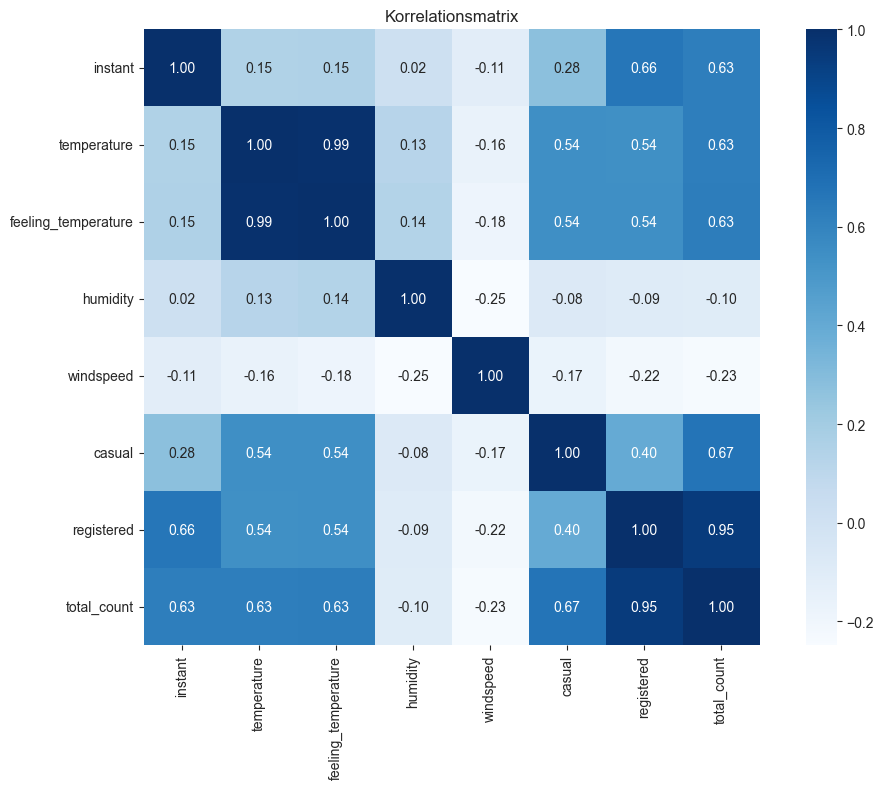

#### **Figure 1:** List of Categorical and Numerical Variables

In [10]:
# Correlation matrix (heatmap) 
def plot_correlation_matrix(df, numerical_features):    
    """
    Plot a correlation matrix heatmap for numerical features in the DataFrame.
    
    Parameters:
    - df: DataFrame containing the data
    - numerical_features: List of numerical feature names
    """
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numerical_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True)
    plt.title('Korrelationsmatrix')
    plt.show()
    display(Markdown("#### **Figure 1:** List of Categorical and Numerical Variables"))

# Plot the correlation matrix
plot_correlation_matrix(day_bike, numerical_variables)

The pair plot was generated using Seaborn. The column ``instant``, which functions as an index and carries no analytical value, was excluded from the plot.This visualization provides an overview of the distributions and relationships between every pair of numerical features. The pair plot provides a comprehensive matrix of visualizations to explore the relationships between the numerical variables. The diagonal cells show the univariate distribution of each variable using kernel density estimation (KDE), which is essential for understanding their individual spread, skewness, and modality. The off-diagonal cells reveal the bivariate relationships. In the upper triangular cells, regression lines are superimposed on scatter plots, offering a clear visual indication of the direction and strength of linear relationships between any two features. Complementing this, the lower triangular cells contain KDE contour plots that illustrate the density of observations, helping to highlight data clusters and the shape of the joint distributions.

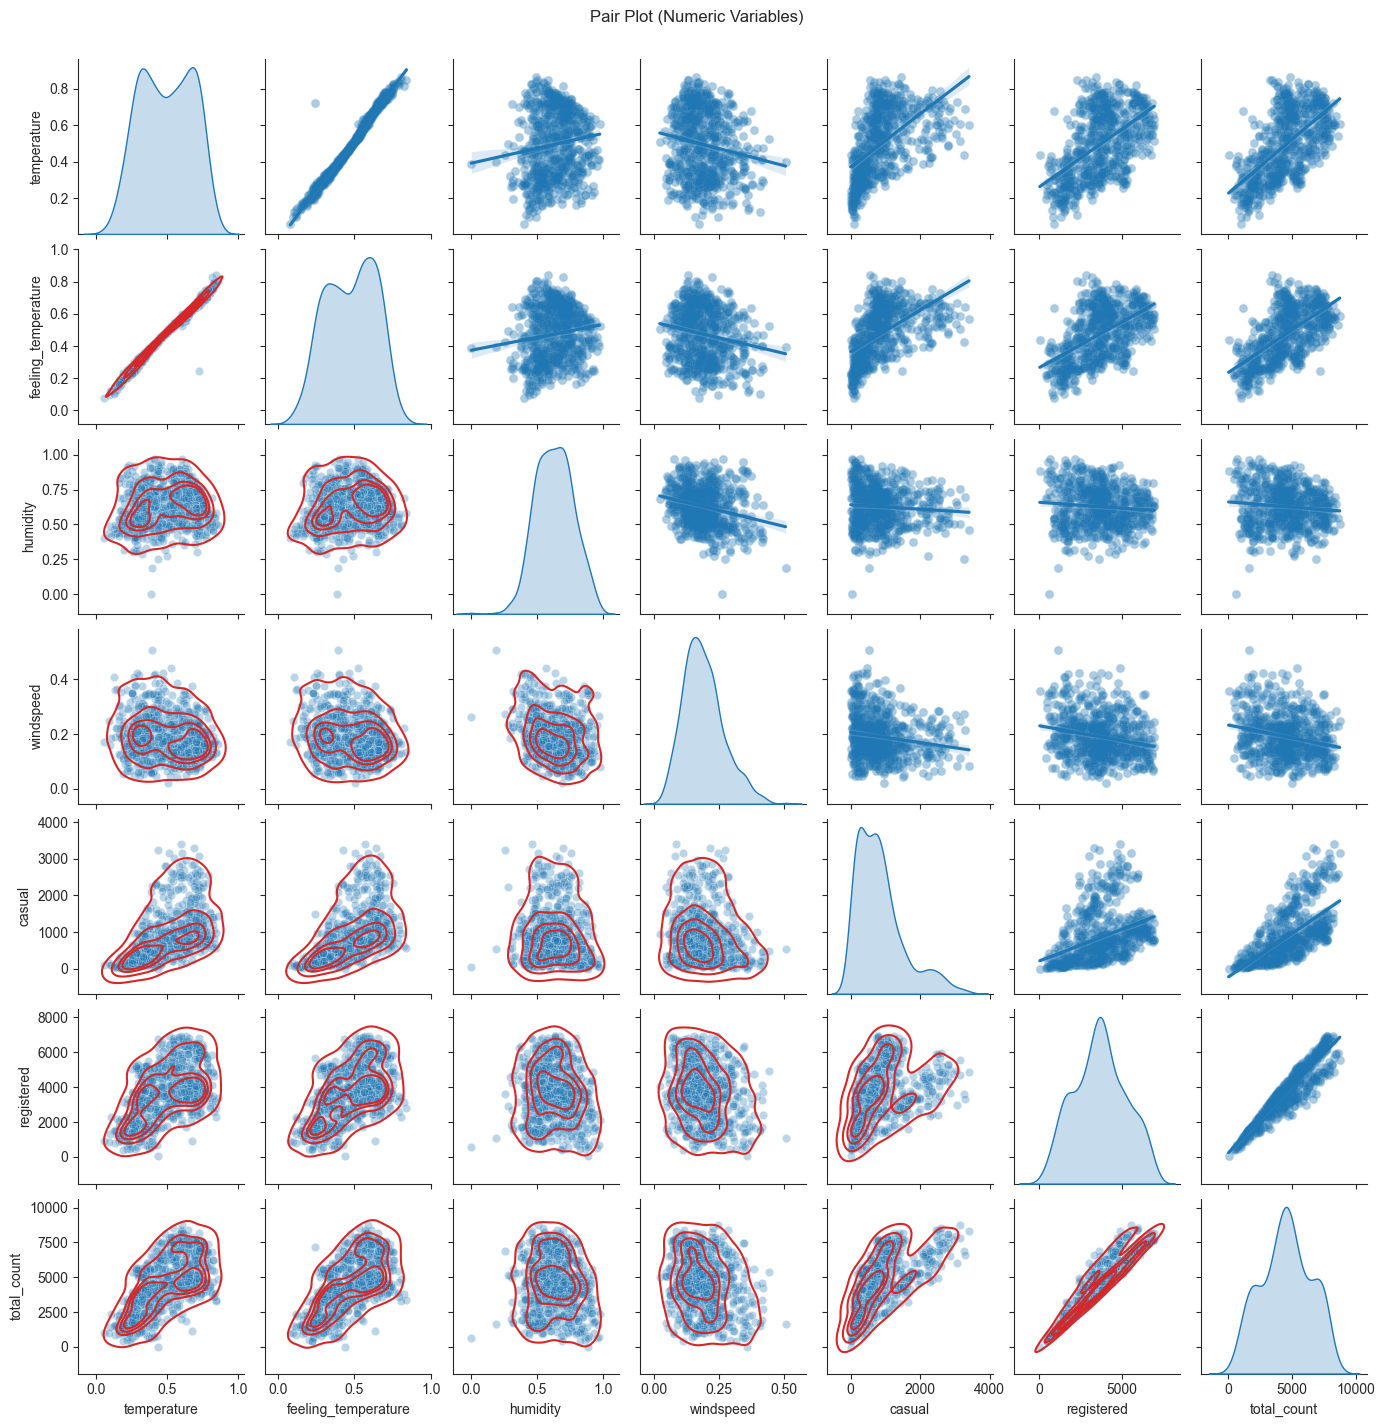

#### **Figure 2:** Pair plot of Numerical Variables

In [11]:
# Exclude 'instant' from numerical variables
num_vars = [col for col in numerical_variables if col != 'instant']
data = day_bike[num_vars]

# Optional: custom palette
sns_c = sns.color_palette()

g = sns.pairplot(
    data=data,
    diag_kind='kde',
    height=2,
    corner=False,
    plot_kws={'alpha': 0.3}
)

#  Lower triangular cells: KDE contours
g.map_lower(
    sns.kdeplot,
    levels=5,
    color=sns_c[3]
)

# Upper triangular cells: Regression lines
g.map_upper(
    sns.regplot,
    color=sns_c[0],
    scatter_kws={'alpha': 0.1}
)

# Adjust title
g.fig.suptitle('Pair Plot (Numeric Variables)', y=1.02)

plt.show()
display(Markdown("#### **Figure 2:** Pair plot of Numerical Variables"))

The analyse of the correlaion heatmap and the pair plot indicates that the variables ``casual`` and ``registered`` have extremely high correlations with ``total_count`` (0.67 and 0.95). This is expected, as ``total_count`` is the direct sum of these two columns. Including casual and registered as predictors in a model to predict ``total_count`` would represent data leakage and lead to an unrealistically optimistic model performance. Therefore, these variables must be excluded from the feature set for the final predictive model.Additionally there is a nearly perfect positive correlation of 0.99 between ``temperature`` and ``feeling_temperature``. As these two variables contain redundant information, including both in a model would lead to significant multicollinearity issues. Consequently, the ``feeling_temperature`` variable will be excluded from further analysis.

The target variable, total_count, shows a strong positive correlation with temperature (0.63). This confirms the intuitive assumption that warmer weather is associated with more bike rentals. Conversely, there are weak to moderate negative correlations with ``humidity`` (-0.10) and ``windspeed`` (-0.23)



In [12]:
# Remove specified columns from the numerical_variables list
cols_to_remove = ['casual', 'registered', 'feeling_temperature', 'instant']
numerical_variables = [col for col in numerical_variables if col not in cols_to_remove]


To confirm that multicollinearity had been resolved after removing the highly correlated variables, we calculated the Variance Inflation Factor (VIF) for each remaining numerical predictor. The VIF measures how much the variance of a regression coefficient is inflated by the presence of correlated features; values above 5 are commonly taken as evidence of problematic multicollinearity. As reported in Table 8, the VIF values for **temperature**, **humidity**, and **wind speed** are all close to 1, indicating that the predictors are effectively independent and that multicollinearity is no longer an issue.


In [13]:
# DataFrame for VIF calculation (without NaNs)
X = day_bike[numerical_variables].dropna()

# Add constant column (for VIF calculation)
X['constant'] = 1

# Calculate VIF values
vif_data = pd.DataFrame({
    'feature': numerical_variables,
    'VIF': [
        variance_inflation_factor(X.values, i)
        for i in range(len(numerical_variables))
    ]
})
display(Markdown("#### **Table 8:** Variance Inflation Factor (VIF)"))

print(vif_data)


#### **Table 8:** Variance Inflation Factor (VIF)

       feature       VIF
0  temperature  1.761323
1     humidity  1.171217
2    windspeed  1.153174
3  total_count  1.854926


##### **Individual Feature Diagnostics**

Following the initial correlation analysis, this section transitions to a more detailed diagnostic check for each individual predictor. A simple linear regression model is fitted for each of the final numerical features (temperature, humidity, and windspeed) against the total_count target.
By analyzing the model summary and a standard set of diagnostic plots for each regression, we will systematically look for several common problems:

- Significance and Influence
- Non-linearity of the response-predictor relationships
- Heteroscedasticity
- Outliers and High-Leverage Points



### **Regression result: total_count ~ temperature**

#### **Table 9:** Results OLS-Model for temperature

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     473.5
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           2.81e-81
Time:                        19:34:39   Log-Likelihood:                -6386.8
No. Observations:                 731   AIC:                         1.278e+04
Df Residuals:                     729   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1214.6421    161.164      7.537      

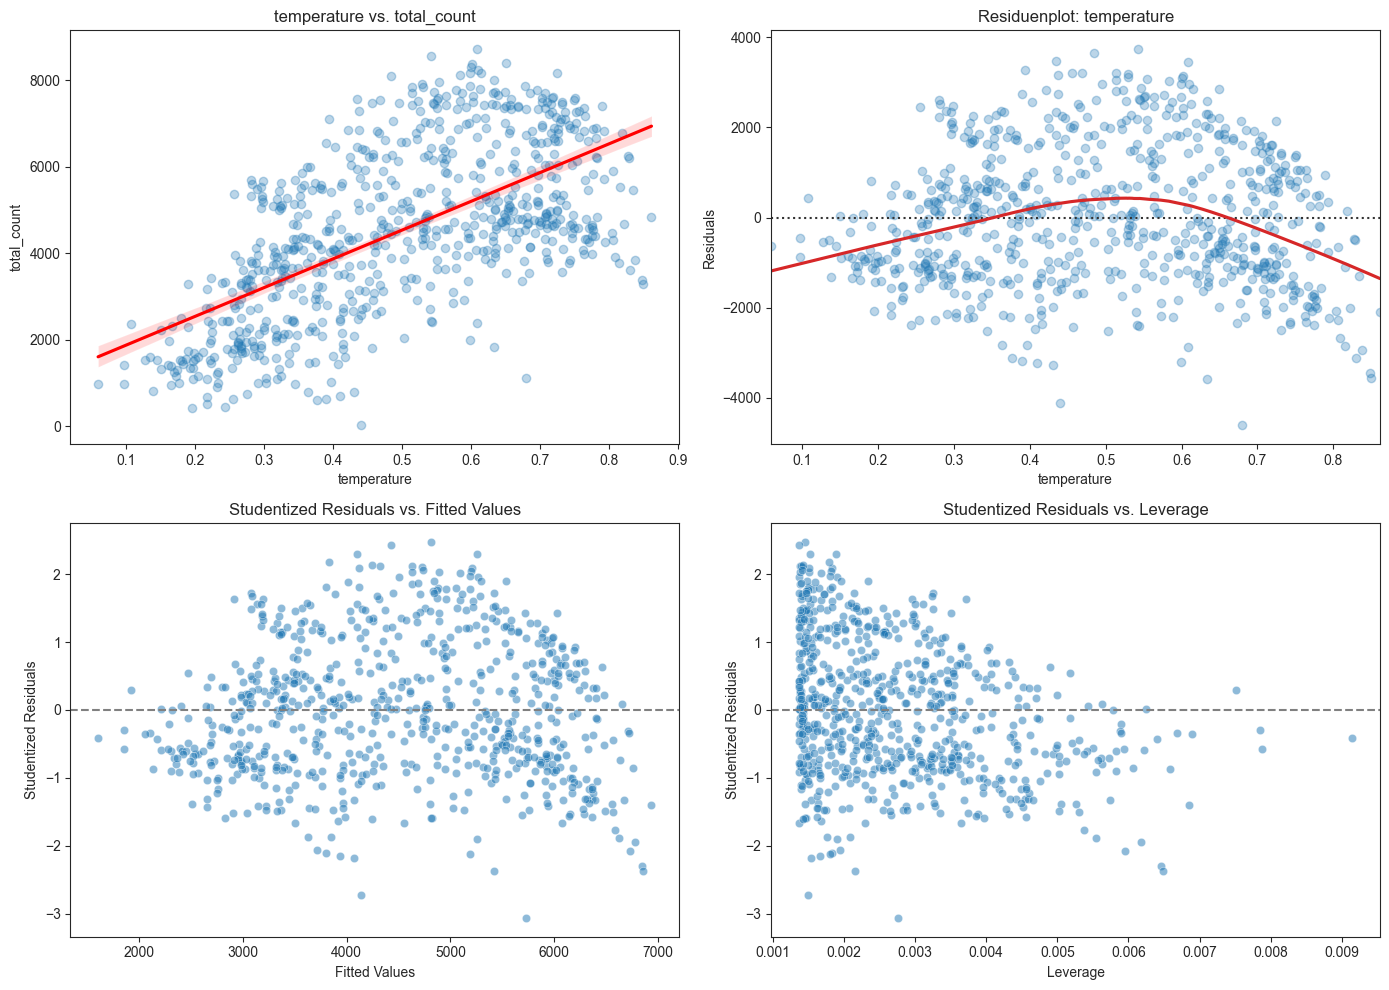

#### **Figure 3:** Regression diagnostics for temperature

---

### **Regression result: total_count ~ humidity**

#### **Table 10:** Results OLS-Model for humidity

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.462
Date:                Tue, 15 Jul 2025   Prob (F-statistic):            0.00645
Time:                        19:34:41   Log-Likelihood:                -6566.0
No. Observations:                 731   AIC:                         1.314e+04
Df Residuals:                     729   BIC:                         1.315e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5363.9865    322.679     16.623      0.0

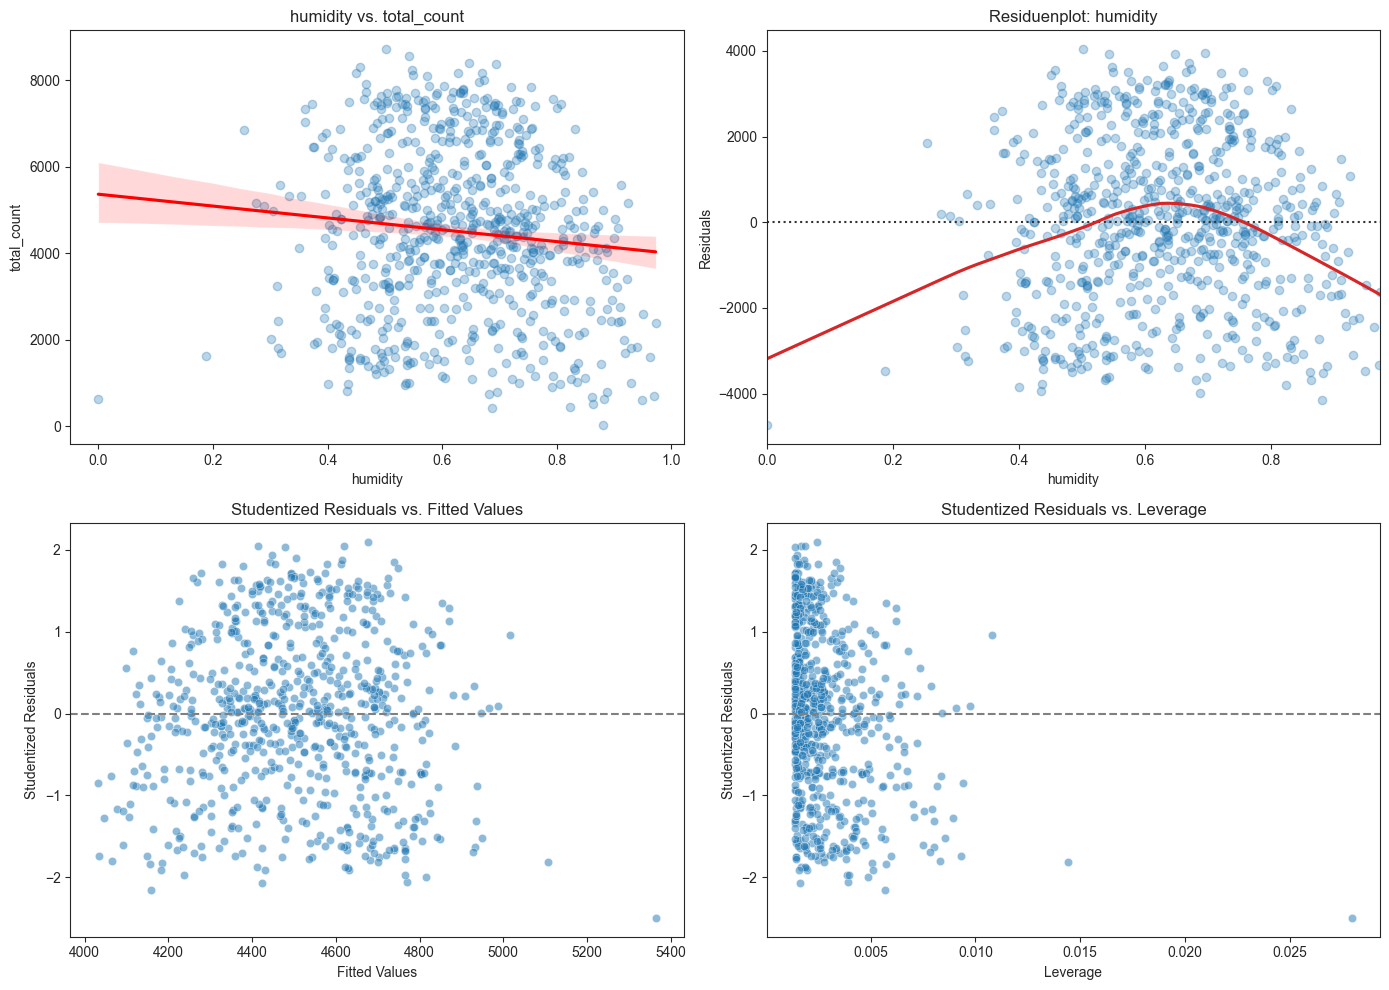

#### **Figure 4:** Regression diagnostics for humidity

---

### **Regression result: total_count ~ windspeed**

#### **Table 11:** Results OLS-Model for windspeed

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     42.44
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           1.36e-10
Time:                        19:34:43   Log-Likelihood:                -6549.0
No. Observations:                 731   AIC:                         1.310e+04
Df Residuals:                     729   BIC:                         1.311e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5621.1529    185.062     30.374      0.0

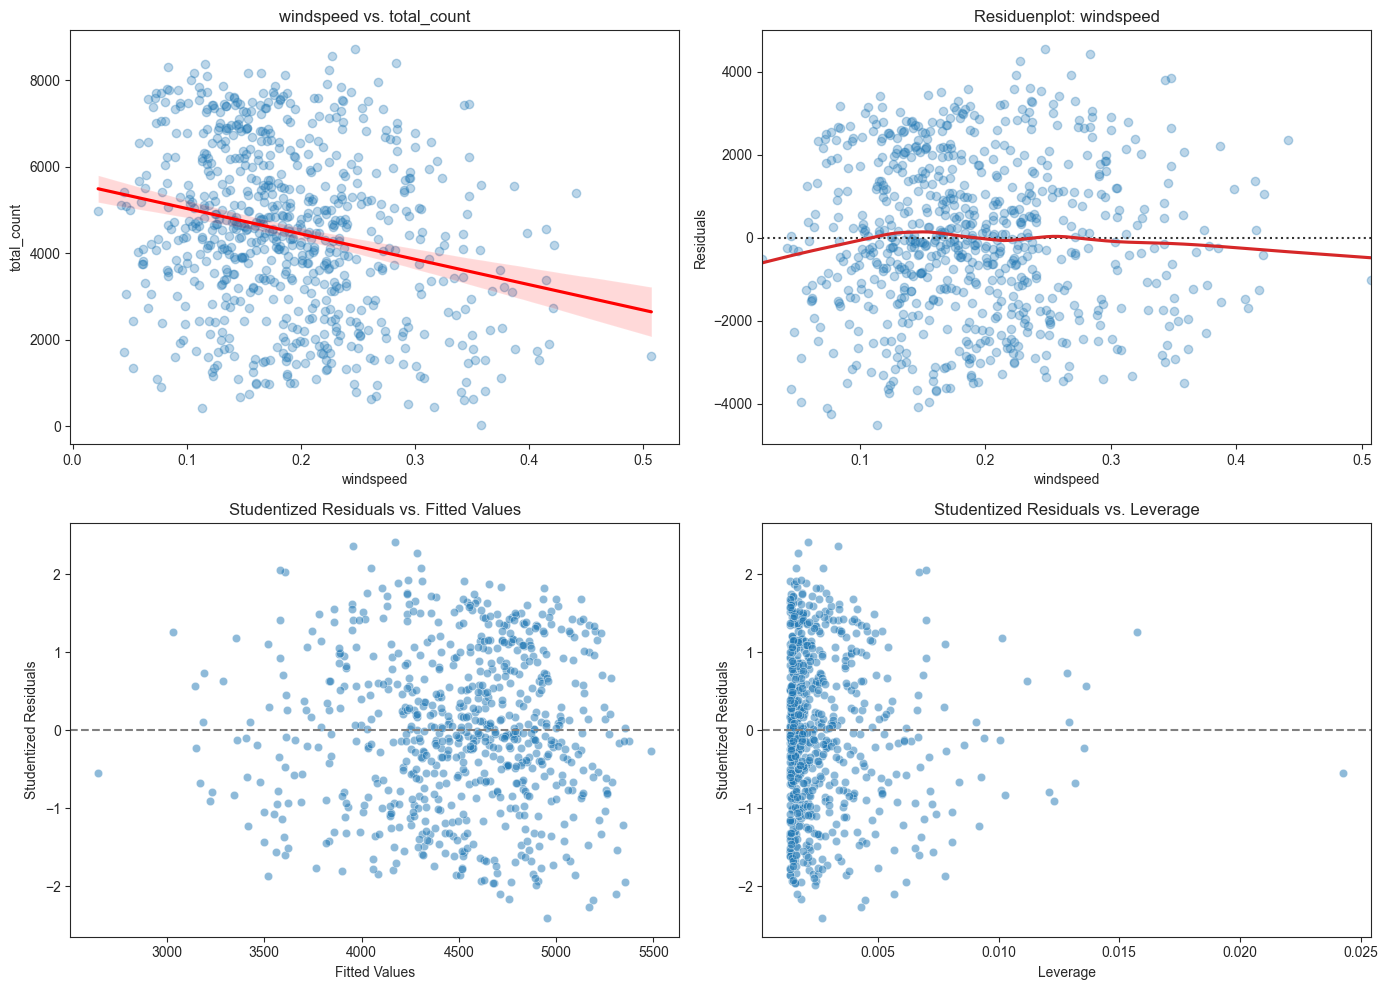

#### **Figure 5:** Regression diagnostics for windspeed

---

In [14]:
features = ['temperature', 'humidity', 'windspeed']
target = 'total_count'
t=9
f=3
# Dict to hold fitted models
models = {}
for feat in features:
    # 1. Regression with statsmodels
    X = sm.add_constant(day_bike[feat])

    model = sm.OLS(day_bike[target], X).fit()
    
    # Store model for later access
    models[feat] = model
    
    # Calculate diagnostic values
    influence = model.get_influence()
    stud_residuals = influence.resid_studentized_internal
    leverage = influence.hat_matrix_diag
    
    # 2. Model summary output
    display(Markdown(f"### **Regression result: {target} ~ {feat}**"))
    display(Markdown(f"#### **Table {t}:** Results OLS-Model for {feat}"))
    print(model.summary())
    
    # 3. Create a 2x2 grid for the plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Top row: Existing plots ---
    sns.regplot(x=feat, y=target, data=day_bike,
                ax=axes[0, 0], scatter_kws={'alpha': 0.3},
                line_kws={'color': 'red'})
    axes[0, 0].set_title(f'{feat} vs. {target}')
    
    sns.residplot(x=day_bike[feat], y=model.resid,
                  ax=axes[0, 1], lowess=True,
                  scatter_kws={'alpha': 0.3},
                  line_kws={'color': 'C3'})
    axes[0, 1].set_title(f'Residuenplot: {feat}')
    axes[0, 1].set_ylabel("Residuals")

    # --- Bottom row: New diagnostic plots ---
    # Studentized Residuals vs. Fitted Values
    sns.scatterplot(x=model.fittedvalues, y=stud_residuals, ax=axes[1, 0], alpha=0.5)
    axes[1, 0].axhline(0, ls='--', color='gray')
    axes[1, 0].set_title('Studentized Residuals vs. Fitted Values')
    axes[1, 0].set_xlabel('Fitted Values')
    axes[1, 0].set_ylabel('Studentized Residuals')

    # Studentized Residuals vs. Leverage
    sns.scatterplot(x=leverage, y=stud_residuals, ax=axes[1, 1], alpha=0.5)
    axes[1, 1].axhline(0, ls='--', color='gray')
    axes[1, 1].set_title('Studentized Residuals vs. Leverage')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Studentized Residuals')
    
    plt.tight_layout() 
    plt.show()
    display(Markdown(f"#### **Figure {f}:** Regression diagnostics for {feat}"))
    display(Markdown("---"))
    t += 1
    f += 1

**``Temperature``:**

The regression results for temperature (see Table 9) indicate that it is a highly significant predictor of total_count, evidenced by its very low p-value (p < 0.001). The R-squared value of 0.395 suggests that temperature alone explains approximately 39.5% of the variance in daily bike rentals.

The residual plot (Figure 3: top right) displays a distinct inverted U-shape, which is a strong indication that the relationship between temperature and bike rentals is not linear.  This suggests that a simple straight line is insufficient to capture the full relationship, as rental counts appear to level off at higher temperatures. The "Studentized Residuals vs. Fitted Values" plot (Figure 4: bottom left) indicate a roughly constant variance, implying no major issues with heteroscedasticity.  Furthermore, this plot confirms the absence of significant outliers, as no points have a studentized residual greater than ±3. The "Studentized Residuals vs. Leverage" plot (bottom right) shows that no data points exhibit extremely high leverage, meaning no single observation is unduly influencing the model.

**``Humidity``:**

The regression results for humidity is displayed in Table 10. The variable statistically significant (p < 0.05), but its individual explanatory power is very low, with an R-squared value of just 0.01. This indicates that humidity alone explains only about 1% of the variance in daily bike rentals. The model revealed a weak negative relationship, indicating that increased humidity is associated with slightly fewer rentals. 

An examination of the diagnostic plots of Figure 5 reveals further issues. A clear, U-shaped pattern in the residual plot (top right) points to a non-linear relationship, suggesting that both very low and very high humidity levels correspond to lower rental counts than moderate levels. Furthermore, the plot of "Studentized Residuals vs. Fitted Values" (bottom left) confirms the presence of heteroscedasticity, as the variance of the residuals is not constant. In terms of influential data points, the analysis reveals one observation with moderately high leverage, but no points qualify as significant outliers with studentized residuals beyond ±3.


**``Windspeed``:**

An analysis of windspeed (see Table 11) shows that while it is a statistically significant predictor (p < 0.001), its individual influence on the total rental count is limited, with an R-squared value of 0.053. This suggests the variable alone accounts for just over 5% of the variance in bike rentals.

Examining the diagnostic plots (see Figure 6) reveals a more nuanced picture. Unlike the other weather variables, the residual plot (top right) for windspeed does not show a strong, obvious pattern, indicating that the assumption of linearity is not as severely violated. Regarding the error variance, the "Studentized Residuals vs. Fitted Values" plot (bottom left) displays a relatively random scatter of points, suggesting no major issues with heteroscedasticity. Finally, in terms of influential points, the "Studentized Residuals vs. Leverage" plot (bottom right) highlights a few observations with higher leverage due to their greater windspeed values, but none appear to be significant outliers that would unduly distort the model.


**Addressing Non-Linearity with Quadratic Terms**

The previous diagnostic checks revealed clear non-linear relationships for both ``temperature`` and ``humidity``. The distinct U-shaped patterns in their respective residual plots are strong evidence that a simple straight line is insufficient to capture the underlying data structure.

A common and effective strategy to address this type of non-linearity is to introduce a polynomial term into the regression model. By adding a quadratic term (the variable squared), we allow the linear model to fit a curve (a parabola) instead of a straight line. This approach can significantly improve the model's fit by capturing the observed curvature. We will now apply this technique to both ``temperature`` and ``humidity`` to assess the improvement.

## Quadratic Model: total_count ~ temperature + temperature²

#### **Table 12:** Results OLS-Model for temperature

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     301.7
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           3.76e-96
Time:                        19:34:45   Log-Likelihood:                -6349.1
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     728   BIC:                         1.272e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1901.9557    382.391     -4.974   

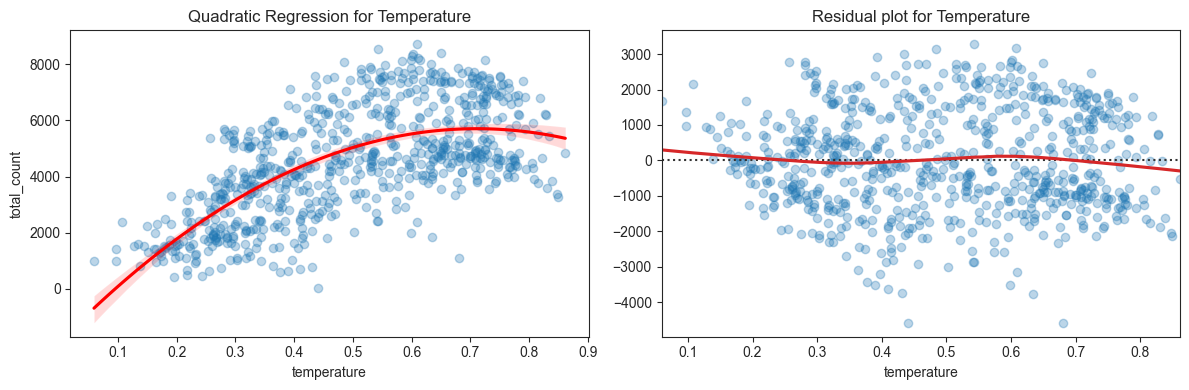

#### **Figure 5:** Regression diagnostics for windspeed

---

## Quadratic Model: total_count ~ humidity + humidity²

#### **Table 13:** Results OLS-Model for humidity

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     30.86
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           1.37e-13
Time:                        19:34:46   Log-Likelihood:                -6539.9
No. Observations:                 731   AIC:                         1.309e+04
Df Residuals:                     728   BIC:                         1.310e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1245.5145    954.185     -1.305      0.1

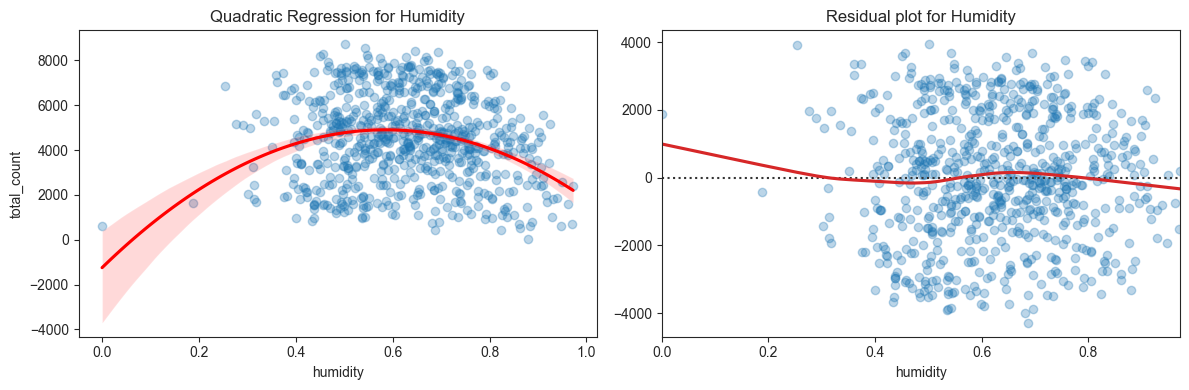

#### **Figure 6:** Regression diagnostics for windspeed

---

In [15]:
t=12
f=5
for feature in ['temperature','humidity']:
    # Introduce quadratic term
    quad_feature_name = f'{feature}2'
    day_bike[quad_feature_name] = day_bike[feature]**2

    # Define features and fit the model
    X = sm.add_constant(day_bike[[feature, quad_feature_name]])
    model_poly = sm.OLS(day_bike['total_count'], X).fit()

    # Display model summary
    display(Markdown(f"## Quadratic Model: total_count ~ {feature} + {feature}²"))
    display(Markdown(f"#### **Table {t}:** Results OLS-Model for {feature}"))
    print(model_poly.summary())

    # Plot the results
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Quadratic regression plot
    sns.regplot(x=feature, y='total_count', data=day_bike, order=2,
                ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[0].set_title(f'Quadratic Regression for {feature.capitalize()}')
    
    # Plot 2: Residual plot
    sns.residplot(x=day_bike[feature], y=model_poly.resid,
                  ax=axes[1], lowess=True, scatter_kws={'alpha':0.3},
                  line_kws={'color':'C3'})
    axes[1].set_title(f'Residual plot for {feature.capitalize()}')
    
    plt.tight_layout()
    plt.show()
    display(Markdown(f"#### **Figure {f}:** Regression diagnostics for {feat}"))
    display(Markdown("---")) # Add a separator
    t= t + 1
    f = f + 1

**``Temperature``:**

The analysis of the quadratic model for temperature shows a significant improvement over the simple linear model. The model summary reveals that the new  $temperature^2$ term is highly statistically significant (p < 0.001). Furthermore, the Adjusted R-squared value has increased substantially from 0.395 to 0.435, indicating that the quadratic model provides a better fit to the data.

This improvement is visually confirmed by the diagnostic plots in Figure 5. The quadratic regression curve (left) now more accurately captures the relationship where rental counts level off at higher temperatures. Most importantly, the residual plot (right) no longer exhibits the strong inverted U-shape seen previously. The residuals are now more randomly scattered around the zero line, confirming that adding the quadratic term has successfully addressed the non-linearity problem for this variable.

The quadratic model fits the data better because it captures a more realistic, non-linear story about human behavior. While a simple linear model assumes that every degree of temperature increase has the same effect, the quadratic model reflects the concept of diminishing returns.

Specifically, it shows that at low temperatures, a warming trend has a strong positive impact on bike rentals. However, as the temperature becomes comfortably warm, the positive effect of each additional degree lessens, causing the rental count to level off. The model can also capture a potential decrease in ridership at extremely high temperatures, an effect a simple linear model cannot represent.


**``Humidity``:**

Similar to temperature, the quadratic model for humidity shows a marked improvement. The new $humidity^2$ term is statistically significant, and the Adjusted R-squared has increased from 0.009 to 0.045. While the overall explanatory power remains low, this is a substantial relative improvement.

The diagnostic plots confirm the better fit. The quadratic regression curve (left) now effectively models the U-shaped relationship where rental counts are lower at both very low and very high humidity levels. The new residual plot (right) shows that the previous strong pattern has been largely mitigated, resulting in a more random scatter of points around the zero line. This confirms that adding a quadratic term was a successful strategy for this variable as well.

The model suggests that bike rentals peak at moderate humidity levels, while both very low and very high humidity suppress ridership. Very low humidity can be uncomfortable, while very high humidity feels "muggy" and oppressive, making physical activities like cycling less pleasant. The quadratic model successfully captures this preference for a comfortable, moderate humidity range, which a simple linear model could not.

To further quantify and visualize the presence of unusual data points in the numerical features, boxplots were generated for each variable. Boxplots are a useful tool for displaying the distribution of the data, showing the median, interquartile range (IQR), and identifying potential high leverage points.

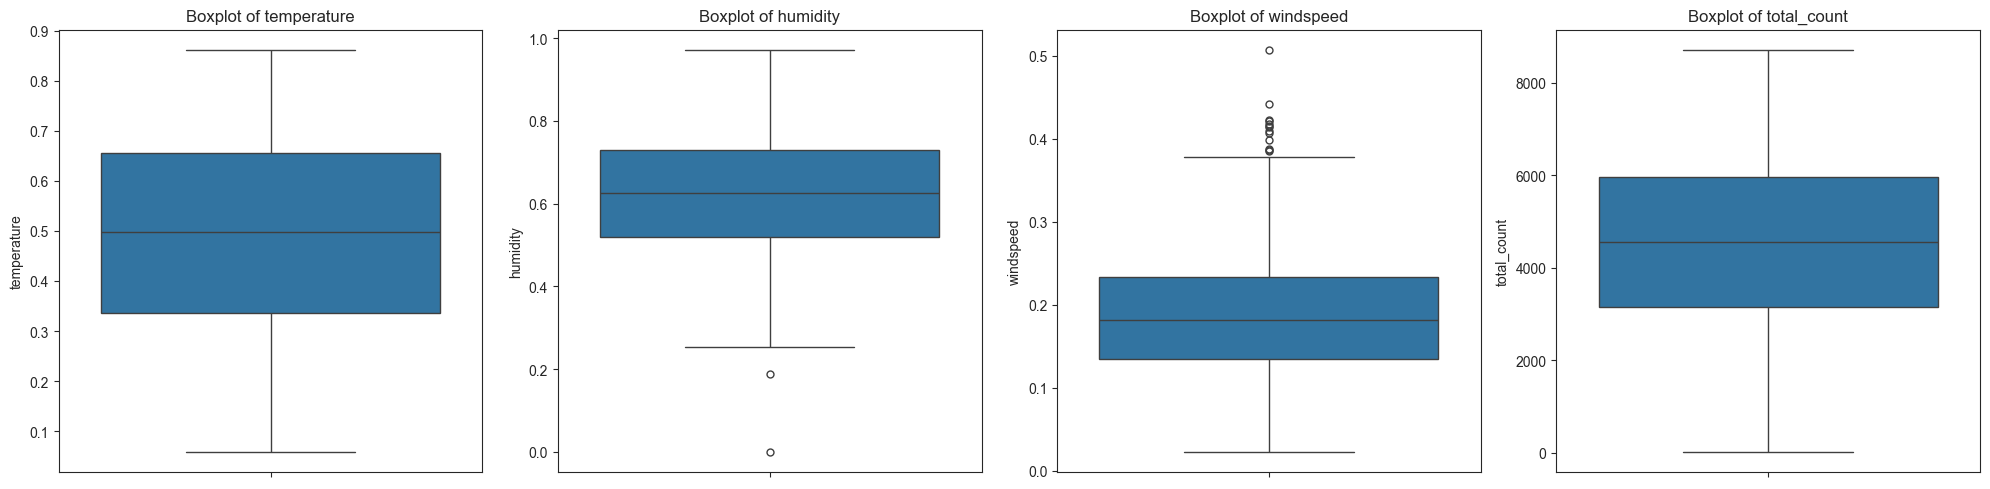

#### **Figure 7 :** Boxplot of Numerical Variables

In [16]:
# Boxplots for Numerical Features to identify high leverage points

# List of numerical features to inspect
num_features = ['temperature', 'humidity', 'windspeed', 'total_count']



# Create one row of subplots, one boxplot per feature
fig, axes = plt.subplots(nrows=1,
                         ncols=len(num_features),
                         figsize=(20, 5),
                         sharey=False)

# Loop over features and axes to draw boxplots
for ax, feature in zip(axes, num_features):
    sns.boxplot(y=day_bike[feature],
                ax=ax,
                color='C0',
                fliersize=5,
                linewidth=1)
    ax.set_title(f'Boxplot of {feature}')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()
display(Markdown(f"#### **Figure 7 :** Boxplot of Numerical Variables"))

An examination of the boxplots in Figure 9 provides several insights into the data distributions. Both temperature and the target variable total_count show relatively symmetrical distributions with no apparent outliers. In contrast, the humidity variable is slightly skewed and includes a few outliers at its lower end, which correspond to days with unusually low humidity. A more pronounced pattern is visible in the windspeed data, which is noticeably right-skewed and exhibits several outliers on the higher end, representing days with exceptionally high wind speeds.

In [17]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# fig, axes = plt.subplots(nrows=4, ncols=2)
# fig.set_size_inches(20, 16)
# plt.subplots_adjust(hspace=0.3)

# # Boxplots for categorical and continuous features
# sns.boxplot(data=day_bike, y="total_count", ax=axes[0][0])
# sns.boxplot(data=day_bike, y="total_count", x="season", ax=axes[0][1])
# sns.boxplot(data=day_bike, y="total_count", x="year", ax=axes[1][0])
# sns.boxplot(data=day_bike, y="total_count", x="weathersit", ax=axes[1][1])
# sns.boxplot(data=day_bike, y="total_count", x="month", ax=axes[2][0])
# sns.boxplot(data=day_bike, y="total_count", x="weekday", ax=axes[2][1])
# sns.boxplot(data=day_bike, x="windspeed", ax=axes[3][0])
# sns.boxplot(data=day_bike, x="humidity", ax=axes[3][1])

# axes[0][0].set(ylabel='Count', title="Box Plot On Count")
# axes[0][1].set(ylabel='Count', title="Box Plot On Count Across Season")
# axes[0][1].set_xticklabels(['spring', 'summer', 'fall', 'winter'])

# axes[1][0].set(ylabel='Count', title="Box Plot On Count Across year")
# axes[1][0].set_xticklabels(['2011', '2012'])

# axes[1][1].set(ylabel='Count', title="Box Plot On Count Across weather")
# axes[1][1].set_xticklabels(['Clear', 'Mist', 'Snow'])

# axes[2][0].set(ylabel='Count', title="Box Plot On Count Across month")
# axes[2][1].set(ylabel='Count', title="Box Plot On Count Across weekday")
# axes[2][1].set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# axes[3][0].set(ylabel='windspeed', title="Box Plot On windspeed")
# axes[3][1].set(ylabel='humidity', title="Box Plot On humidity")

# plt.show()'

#### 2.2.2 Categorical Features

To understand how different categorical variables impact bike rentals, a series of boxplots were generated. Each plot visualizes the distribution of total_count across the different categories of a given feature. This method is effective for comparing the median rental counts and identifying variations in rental patterns based on factors like season, year, or weather conditions.



## Boxplots of Categorical Variables vs. total_count

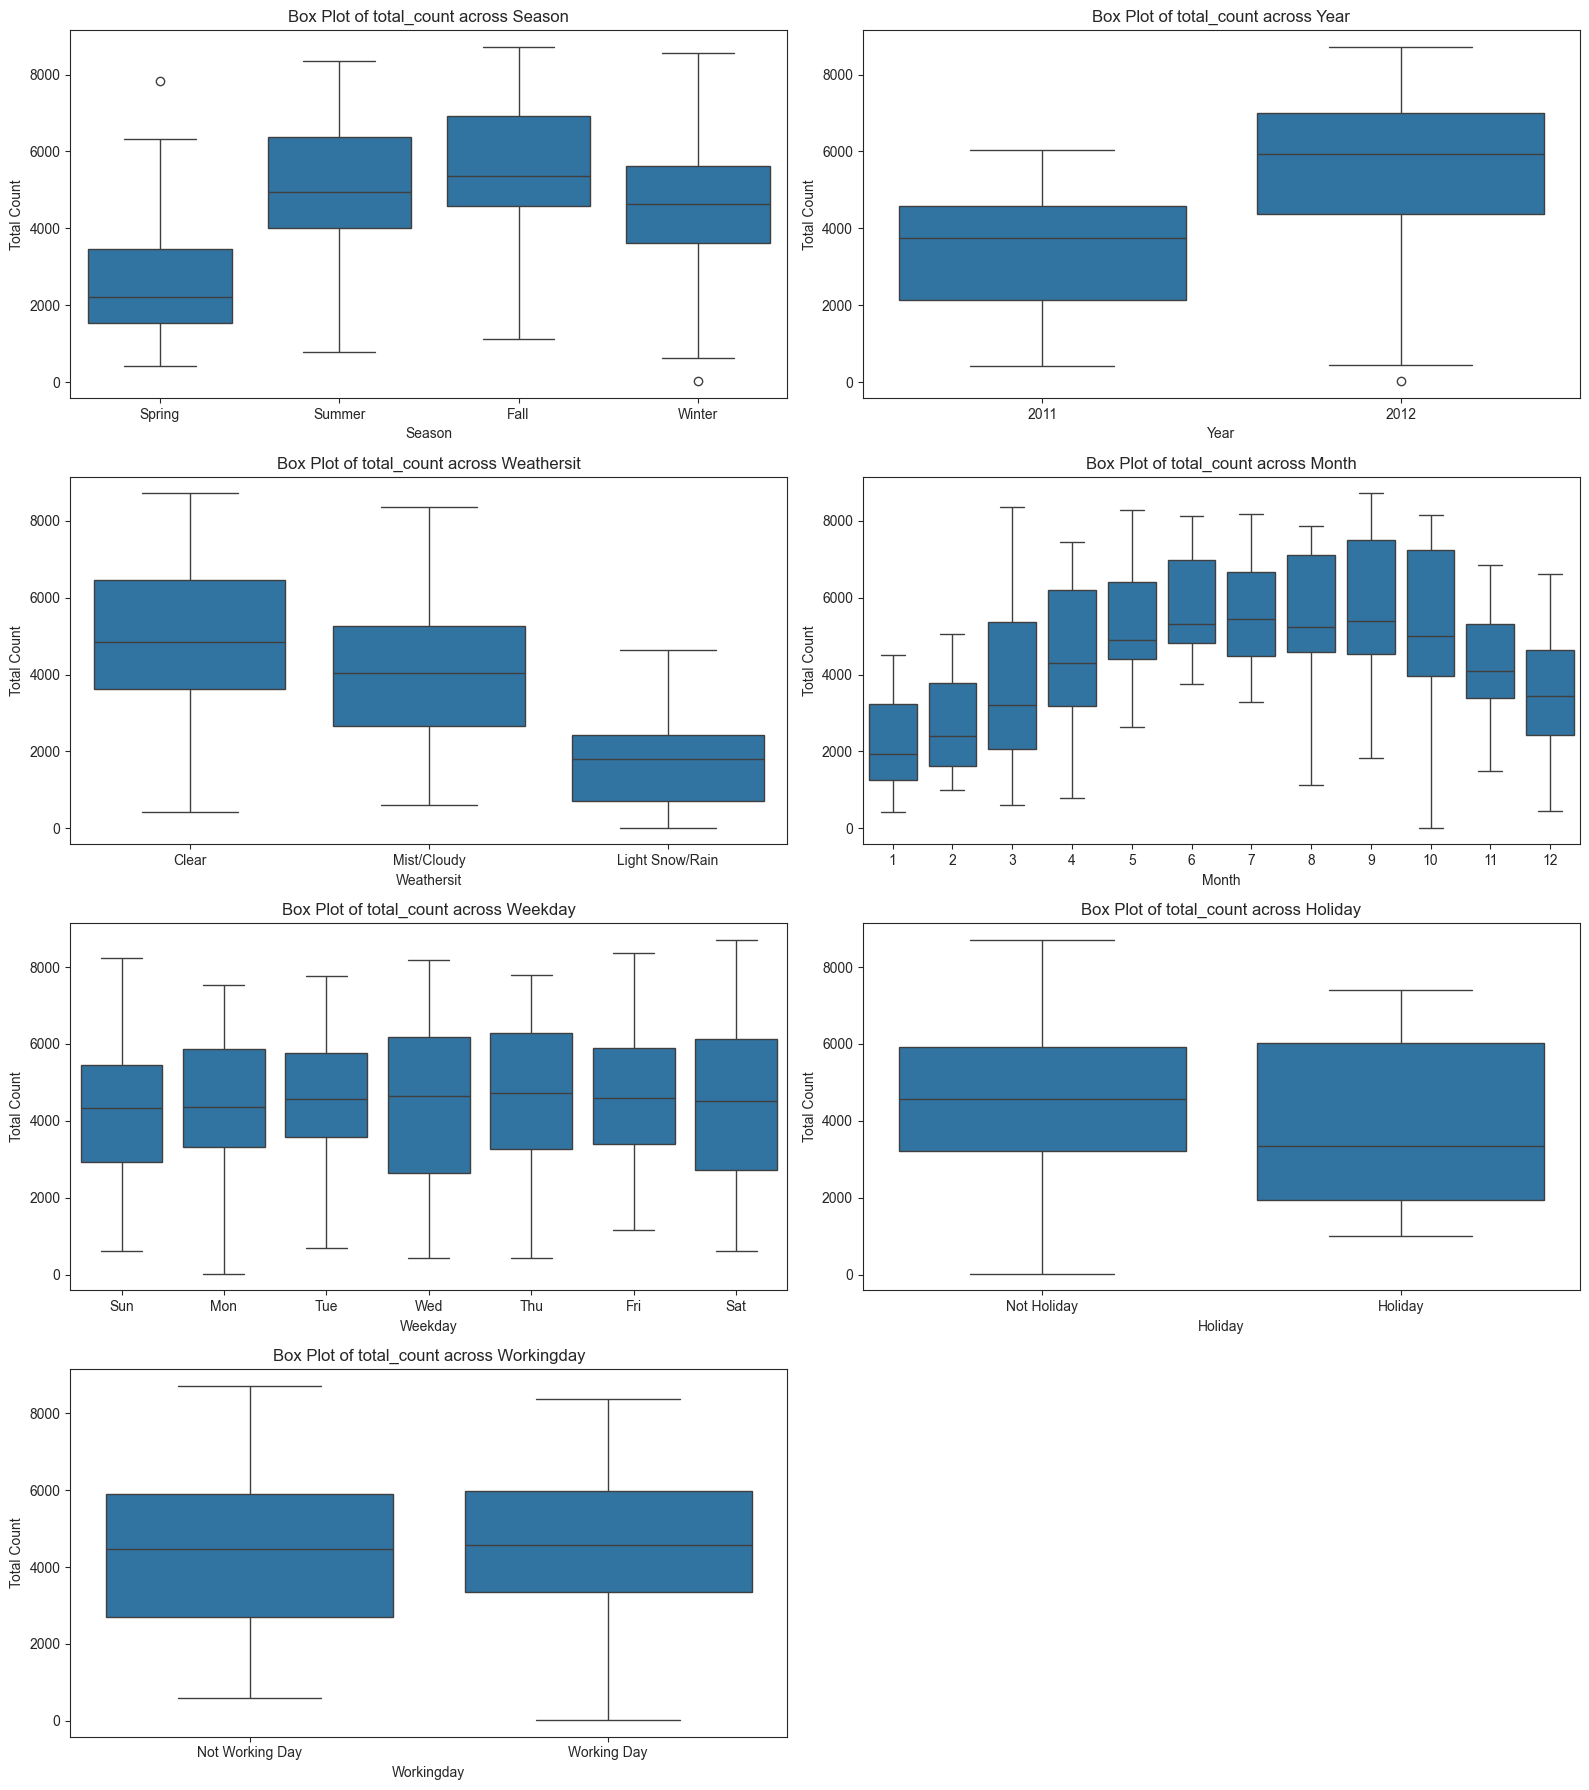

#### **Figure 8:** Boxplots of Categorical Variables vs. Total Count

In [31]:
#Boxplots for Categorical Features vs. Total Count


# Define the categorical features to be plotted against the target variable
cat_features_for_plot = ['season', 'year', 'weathersit', 'month', 'weekday', 'holiday', 'workingday']
target = 'total_count'

# Create a figure and a set of subplots. A 4x2 grid.
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
# Flatten the axes array for easy iteration, which simplifies assigning plots to subplots
axes = axes.flatten()

display(Markdown(f"## Boxplots of Categorical Variables vs. {target}"))

# --- Plotting Loop ---
# Iterate through the list of categorical features and create a boxplot for each.
# 'enumerate' provides an index 'i' and the 'feature' name.
for i, feature in enumerate(cat_features_for_plot):
    ax = axes[i]
    # Create the boxplot using seaborn, assigning it to the current subplot axis
    sns.boxplot(data=day_bike, x=feature, y=target, ax=ax)
    # Set a descriptive title for each subplot
    ax.set_title(f'Box Plot of {target} across {feature.capitalize()}')
    ax.set_ylabel('Total Count')
    ax.set_xlabel(feature.capitalize())

# --- Customizing Labels for better readability ---
# Set both tick positions and labels to avoid the UserWarning
axes[0].set_xticks(ticks=[0, 1, 2, 3], labels=['Spring', 'Summer', 'Fall', 'Winter']) # For 'season'
axes[1].set_xticks(ticks=[0, 1], labels=['2011', '2012']) # For 'year'
axes[2].set_xticks(ticks=[0, 1, 2], labels=['Clear', 'Mist/Cloudy', 'Light Snow/Rain']) # For 'weathersit'
axes[4].set_xticks(ticks=range(7), labels=['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # For 'weekday'
axes[5].set_xticks(ticks=[0, 1], labels=['Not Holiday', 'Holiday']) # For 'holiday'
axes[6].set_xticks(ticks=[0, 1], labels=['Not Working Day', 'Working Day']) # For 'workingday'

# Hide the last subplot if it's unused (since we have 7 plots in a 4x2 grid)
axes[7].set_visible(False)

# Adjust the layout automatically to prevent titles and labels from overlapping
plt.tight_layout()
# Display the generated
plt.show()
display(Markdown("#### **Figure 8:** Boxplots of Categorical Variables vs. Total Count"))

An analysis of the categorical features reveals distinct patterns in bike rental usage. A clear seasonal trend is evident, with ridership peaking in the Fall and Summer while being lowest in the Spring. This trend is further illuminated by the monthly data, which shows the highest rental counts occurring between May and October. A significant growth in the system's popularity is also visible, with the median number of rentals in 2012 being substantially higher than in 2011.

Rider behavior also varies with the type of day. As expected, the weather situation is a strong determinant; clear days show the highest usage, while days with light snow or rain have the lowest. Interestingly, while weekdays have a stable rental pattern, weekends show a much wider distribution, indicating more variability. The distinction between working and non-working days further clarifies this, showing higher median rentals on working days, while holidays have a noticeably lower ridership compared to non-holidays.

Collectively, these distinct variations in rental distributions confirm that all the analyzed categorical features have a significant influence on the total_count and are therefore important for the predictive model.

In [19]:
# # New Cell: Analysis of Categorical Variables
# from IPython.display import display, Markdown

# def analyze_categorical_features(df, cat_features, target=None):
#     """
#     Analyze categorical variables:
#     - Display frequency distributions
#     - Plot countplots for each feature
#     - (Optional) Aggregate by feature and calculates the mean of the target variable
#     """
#     display(Markdown("## Analysis of Categorical Variables"))
    
#     for feature in cat_features:
#         display(Markdown(f"### Feature: {feature}"))
        
#         # Display the frequency distribution
#         counts = df[feature].value_counts()
#         display(counts)
        
#         # Create a countplot
#         plt.figure(figsize=(8, 4))
#         sns.countplot(x=feature, data=df, order=counts.index)
#         plt.title(f'Distribution of {feature}')
#         plt.xticks(rotation=45)
#         plt.show()
        
#         # Optional analysis: aggregate target variable if provided
#         if target is not None and target in df.columns:
#             group_stats = df.groupby(feature)[target].mean().sort_values(ascending=False)
#             display(Markdown(f"**Average {target} by {feature}:**"))
#             display(group_stats)
#             plt.figure(figsize=(8, 4))
#             sns.barplot(x=group_stats.index, y=group_stats.values)
#             plt.title(f'Average {target} by category in {feature}')
#             plt.xticks(rotation=45)
#             plt.ylabel(f'Average {target}')
#             plt.show()

# # Calling the function with our categorical variables
# analyze_categorical_features(day_bike, categorical_variables, target="total_count")

Based on the initial diagnostic analysis of individual features, which hinted at the existence of some high-leverage points, a more in-depth analysis is now performed. The previous visual inspection was limited to single-variable models; therefore, to gain a more comprehensive understanding and to quantitatively identify influential points, this analysis uses a multivariate regression model that considers all relevant predictors simultaneously. The procedure involves several key steps as reflected in the code.

First, a complete feature set is prepared by combining the final numerical predictors (temperature, humidity, windspeed) with the categorical features. To make the categorical data suitable for a regression model, they are transformed into a numerical format using one-hot encoding (``pd.get_dummies``) with the ``drop_first=True`` parameter used to avoid perfect multicollinearity among the new dummy variables. These are then combined with the original numerical features to create a complete feature set.

Next, a custom function (``detect_outliers_and_leverage``) fits an Ordinary Least Squares (OLS) regression model to the full dataset. After fitting, this function calculates two key influence measures for each data point The studentized residuals, which identify potential outliers by measuring how large the prediction error is, and the leverage. A point with high leverage is distant from other points in the feature space and can disproportionately pull the regression line towards it, with the threshold here calculated as

``leverage_thresh`` = $(\frac{p+1}{n})$ * ``leverage_factor``, 

where $p$ is number of number of predictors and n number of observations. The ``leverage_factor`` is a multiplier to control the sensitivity of the detection of high leverage points. The function then flags a point as a potential outlier if its studentized residual is greater than ±3, and as a high-leverage point if its leverage value exceeds the calculated threshold.

In [ ]:

def detect_outliers_and_leverage(df, feature_cols, target_col, outlier_factor=3.0, leverage_factor=1.0):
    """
    Fit an OLS regression model on the specified features and target,
    compute influence measures and flags:
      - is_potential_outlier: |studentized residual| > outlier_factor
      - is_high_leverage: hat value > (p+1)/n
    """
    # Prepare design matrix
    X = df[feature_cols].copy()
    X = sm.add_constant(X)
    y = df[target_col]

    # Fit OLS model
    model = sm.OLS(y, X).fit()

    # Influence measures
    infl = model.get_influence()
    hat_vals = infl.hat_matrix_diag
    stud_resid = infl.resid_studentized_internal

    # Thresholds
    n, p = X.shape[0], X.shape[1] - 1
    print(n, p )
    leverage_thresh = ((p + 1) / n) * leverage_factor
    print(leverage_thresh)

    # Flags
    is_outlier = np.abs(stud_resid) > outlier_factor
    is_high_lev = hat_vals > leverage_thresh

    # Build results
    results = pd.DataFrame({
        'residuals': model.resid,
        'standardized_residuals': stud_resid,
        'leverage': hat_vals,
        'is_potential_outlier': is_outlier,
        'is_high_leverage': is_high_lev
    }, index=df.index)

    return results, model


In [37]:
# Applying the Outlier/Leverage Detection Function


# 1. Define the feature sets and the target variable
numerical_features = ['temperature', 'humidity', 'windspeed']
# Note: 'month' and 'weekday' can be treated as categorical
categorical_features = ['season', 'year', 'month', 'weekday', 'weathersit', 'holiday', 'workingday']
target_col = 'total_count'

# 2. Create one-hot encoded features from the categorical variables
# Using drop_first=True to avoid perfect multicollinearity
day_bike_dummies = pd.get_dummies(day_bike[categorical_features], 
                                  columns=categorical_features, 
                                  drop_first=True, 
                                  dtype=float)

# 3. Combine the numerical features and the new dummy variables
X_full = pd.concat([day_bike[numerical_features], day_bike_dummies], axis=1)

# The function needs a single DataFrame with both features and target
df_for_model = pd.concat([X_full, day_bike[target_col]], axis=1)

# 4. Get the final list of all predictor columns
all_feature_cols = X_full.columns.tolist()

# 5. Call the detection function with the prepared data
# We can adjust the outlier_fraction, e.g., to 5% for the full model
influence_df, full_model = detect_outliers_and_leverage(
    df=df_for_model,
    feature_cols=all_feature_cols,
    target_col=target_col,
    leverage_factor=2.0,  # Adjust leverage factor 
)

# 6. Display the summary of the fitted regression model
display(Markdown("## Full Regression Model Summary"))
print(full_model.summary())

# 7. Display the points that were flagged as either potential outliers or high-leverage
display(Markdown("## Identified Potential Outliers and/or High-Leverage Points"))
problematic_points = influence_df[
    (influence_df['is_potential_outlier']) | (influence_df['is_high_leverage'])
]
display(problematic_points)

print(f"\nTotal number of problematic points found: {len(problematic_points)}")

731 28
0.07934336525307797


## Full Regression Model Summary

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     145.3
Date:                 Di, 15 Jul 2025   Prob (F-statistic):          1.49e-266
Time:                        20:30:59   Log-Likelihood:                -5881.0
No. Observations:                 731   AIC:                         1.182e+04
Df Residuals:                     703   BIC:                         1.195e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1543.5518    235.129      6.565   

## Identified Potential Outliers and/or High-Leverage Points

,residuals,standardized_residuals,leverage,is_potential_outlier,is_high_leverage
68,-849.397951,-1.210338,0.168286,False,True
89,1129.975980,1.547447,0.099525,False,True
104,88.644706,0.120317,0.083322,False,True
184,2458.796250,3.322201,0.074965,True,False
238,-2301.267669,-3.058909,0.044202,True,False
265,-2702.681903,-3.631066,0.064408,True,False
301,-246.595684,-0.334712,0.083373,False,True
314,675.277341,0.915233,0.080683,False,True
339,1274.780209,1.729367,0.082384,False,True
359,273.015661,0.370957,0.085271,False,True



Total number of problematic points found: 23


# 3. Modeling and Optimization

Modeling and Optimization Strategy：

In this section, we define the machine learning task and modeling approach used in the project.

The target variable in this dataset is `total_count`, which represents the total number of bike rentals per day. Since `total_count` is a continuous numerical value rather than a category or label, the task is defined as a **regression problem**.

We explore and compare four different regression models, each building on or differing from the previous by applying advanced machine learning concepts:

- **Linear Regression**: A baseline model assuming a linear relationship between features and target. Simple and interpretable but limited in capturing complex patterns. Later, polynomial features will be introduced to this model to better capture nonlinear relationships.

- **Ridge Regression**: Extends linear regression with L2 regularization (penalty on the squared magnitude of coefficients) to prevent overfitting, especially when features are many or correlated. Controls complexity better than Linear Regression.

- **Lasso Regression**: Similar to Ridge but uses L1 regularization (penalty on the absolute value of coefficients). Besides reducing overfitting, it can set some coefficients to zero, performing automatic feature selection which Ridge cannot.

- **Random Forest Regression**: An ensemble of decision trees that combines multiple trees to improve accuracy and generalization. It models complex interactions and nonlinearities better than a single tree and reduces overfitting by averaging.

To further enhance model performance and ensure robust generalization, we apply machine learning techniques such as hyperparameter tuning using GridSearchCV with cross-validation:

- **Ridge and Lasso Regression**: The key hyperparameter tuned is `alpha`, the regularization strength. Adjusting `alpha` helps find the optimal trade-off between underfitting and overfitting by controlling the amount of shrinkage applied to the model coefficients.

- **Random Forest Regression**: We tune hyperparameters such as `max_depth` (maximum tree depth), `min_samples_leaf` (minimum samples per leaf), and others. These parameters help balance bias and variance by controlling the complexity of the tree structure.

These optimization steps help prevent overfitting and ensure the models generalize well on unseen data. All models are trained on the training set and evaluated on the test set to compare their predictive performance.

## 3.1 Linear Regression

Step 0: Null Model MSE = 3747654.56
Step 1: Added 'casual', CV MSE: 2654864.10
Step 2: Added 'workingday_1', CV MSE: 1640334.63
Step 3: Added 'year_1', CV MSE: 1041227.67
Step 4: Added 'season_4', CV MSE: 847649.00
Step 5: Added 'temperature', CV MSE: 566539.52
Step 6: Added 'weathersit_3', CV MSE: 511552.58
Step 7: Added 'weathersit_2', CV MSE: 487275.88
Step 8: Added 'month_7', CV MSE: 476919.79
Step 9: Added 'windspeed', CV MSE: 471361.29
Step 10: Added 'weekday_1', CV MSE: 467944.85
Step 11: Added 'weekday_6', CV MSE: 465570.69
Step 12: Added 'month_4', CV MSE: 463928.58
Step 13: Added 'season_3', CV MSE: 462673.41
Step 14: Added 'season_2', CV MSE: 432566.45
Step 15: Added 'temperature2', CV MSE: 420786.56
Step 16: Added 'month_11', CV MSE: 413567.33
Step 17: Added 'weekday_5', CV MSE: 411657.18
Step 18: Added 'weekday_4', CV MSE: 411351.21
Step 19: Added 'holiday_1', CV MSE: 411430.48
Step 20: Added 'month_2', CV MSE: 412154.62
Step 21: Added 'humidity', CV MSE: 412994.61
Step 22

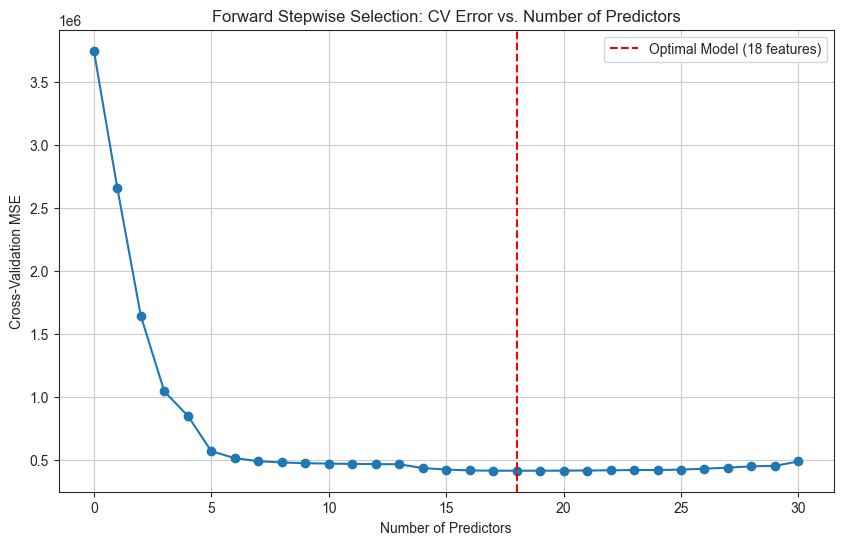

In [22]:
# --- 1. Data Preparation (linear) ---

# Drop columns that are not needed or would cause data leakage
# 'date' is redundant, 'casual' and 'registered' sum up to the target 'total_count'
# 'feeling_temperature' is highly correlated with 'temperature'
df_model_linear = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'])
# Define features (X) and target (y)
X_linear = df_model_linear.drop('total_count', axis=1)
y_linear = df_model_linear['total_count']

# Identify numerical and categorical features for the preprocessor
categorical_features_linear = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_linear = [col for col in X_linear.columns if col not in categorical_features_linear]                                     

# Create a preprocessor for scaling and one-hot encoding
# Using drop='first' to avoid multicollinearity (dummy variable trap)
# Using sparse_output=False to ensure dense arrays for subsequent pipeline steps
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_linear),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_linear)
    ],
    remainder='passthrough'
)

# Get the full list of feature names after preprocessing
preprocessor_linear.fit(X_linear)
ohe_names_linear = preprocessor_linear.named_transformers_['cat'].get_feature_names_out(categorical_features_linear)
all_names_linear = numerical_features_linear + ohe_names_linear.tolist()

def forward_stepwise_selection(X, y, preprocessor, all_feature_names, cv_folds=5):
    """
    Perform forward stepwise selection on the entire dataset using cross-validation.

    Args:
        X (pd.DataFrame): The full feature dataset.
        y (pd.Series): The full target dataset.
        preprocessor (ColumnTransformer): The preprocessor for scaling and encoding.
        all_feature_names (list): A list of all feature names after preprocessing.
        cv_folds (int): The number of folds for cross-validation.

    Return:
        tuple: A tuple containing:
            - pd.DataFrame: A history of MSE and features at each step.
            - list: The list of the best features found.
    """
    remaining_features = all_feature_names.copy()
    selected_features = []
    history_mse = []
    history_features = []

    # Step 0: Calculate Null Model MSE (predicting the mean)
    null_mse = mean_squared_error(y, np.full_like(y, y.mean()))
    history_mse.append(null_mse)
    history_features.append([])
    print(f"Step 0: Null Model MSE = {null_mse:.2f}")

    # Iterate from 1 to the total number of features
    for i in range(len(all_feature_names)):
        best_score_for_step = -np.inf
        best_feature_for_step = None
        
        for feature in remaining_features:
            current_features = selected_features + [feature]
            feature_indices = [all_feature_names.index(f) for f in current_features]
            
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('selector', ColumnTransformer([('selector', 'passthrough', feature_indices)], remainder='drop')),
                ('regressor', LinearRegression())
            ])
            
            # Perform cross-validation on the full dataset
            scores = cross_val_score(pipeline, X, y, cv=cv_folds, scoring='neg_mean_squared_error')
            current_score = scores.mean()
            
            if current_score > best_score_for_step:
                best_score_for_step = current_score
                best_feature_for_step = feature
        
        if best_feature_for_step:
            selected_features.append(best_feature_for_step)
            remaining_features.remove(best_feature_for_step)
            history_mse.append(-best_score_for_step)
            history_features.append(selected_features.copy())
            print(f"Step {i+1}: Added '{best_feature_for_step}', CV MSE: {-best_score_for_step:.2f}")
        else:
            print("No further improvement. Stopping selection.")
            break

    history_df = pd.DataFrame({
        'num_features': range(len(history_mse)),
        'cv_mse': history_mse,
        'features': history_features
    })

    best_model_idx = history_df['cv_mse'].idxmin()
    best_features = history_df.loc[best_model_idx, 'features']
    
    print(f"\nOptimal number of features found: {len(best_features)}")
    print(f"Lowest CV MSE: {history_df.loc[best_model_idx, 'cv_mse']:.2f}")
    
    return history_df, best_features


# --- 2. Run Forward Stepwise Selection ---
history_df_linear, best_features_linear = forward_stepwise_selection(X_linear, y_linear, preprocessor_linear, all_names_linear, cv_folds=5)


# --- 3. Visualize Selection Process ---
plt.figure(figsize=(10, 6))
plt.plot(history_df_linear['num_features'], history_df_linear['cv_mse'], marker='o', linestyle='-')
best_num_features = history_df_linear['cv_mse'].idxmin()
plt.axvline(x=best_num_features, color='r', linestyle='--', label=f'Optimal Model ({best_num_features} features)')
plt.xlabel('Number of Predictors')
plt.ylabel('Cross-Validation MSE')
plt.title('Forward Stepwise Selection: CV Error vs. Number of Predictors')
plt.legend()
plt.grid(True)
plt.show()

We develop a linear regression model to predict the daily total number of bike rentals using weather, temporal and calendar-related features.
We begin by preparing the dataset for modeling, dropping `registered` and `casual` variables, because their sum equals the target varable `total_count`. `Feeling_temperature` is also excluded, since it is highly correlated to temperature. `Date` and `humidity2` are redundant and `instant` is also considered irrelevant for modeling.  
After cleaning, we split the dataset into input featues (`X_linear`) and the target vaiable (`y_linear`). To properly process the data, we categorize the features into numerical and categorical variables.  
We use a `ColumnTransformer` to scale the numerical features and `StandardScaler` and `OneHotEncoder` to one-hot encode the categorical features, dropping the first category to avoid multicollinearity.

To build the model, we use **forward stepwise feature selection**, a greedy algorithm that adds one feature at a time based on model performance. We start with no features and try adding each of the remaining features at each step, and evaluate the resulting model using cross-validation. The feature that leads to the largest improvement and lowest mean squared error is added to the model, we continue the processs until it can not be improved further. The result shows which features were added at each step and the cross-validated mean squared error.  
The **optimal number of features** is **17** and the **lowest cross-validated MSE** is **431 177.76**.

We visualize the relationship between the number of selected features and the corresponding cross-validated MSE. The plot shows a decreasing trend in cross-validated MSE as features are added. The optimal number of features (17) where cross-validated MSE is minimized is highlighted with a vertical dashed red line.

In [23]:
# --- 4. Final Model Evaluation on a Test Set ---
print("\n--- Evaluating Final Model ---")
# Now, split the data to train the final model and evaluate it on unseen data
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

# Create the final pipeline with the best features identified
final_indices_linear = [all_names_linear.index(f) for f in best_features_linear]
final_pipeline_linear = Pipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('selector', ColumnTransformer([('selector', 'passthrough', final_indices_linear)], remainder='drop')),
    ('regressor', LinearRegression())
])

# Fit the final model on the training data
final_pipeline_linear.fit(X_train_lin, y_train_lin)

# Make predictions on the test set
y_pred_lin = final_pipeline_linear.predict(X_test_lin)
test_mse_lin = mean_squared_error(y_test_lin, y_pred_lin)
test_mae_lin = mean_absolute_error(y_test_lin, y_pred_lin)

print(f"Features in the final model: {best_features_linear}")
print(f"Test Set MSE: {test_mse_lin:.2f}")
print(f"Test Set RMSE: {np.sqrt(test_mse_lin):.2f}")
print(f"Test Set MAE: {test_mae_lin:.2f}") 

# Calculate and print R-squared score
r2 = final_pipeline_linear.score(X_test_lin, y_test_lin)
print(f"Test Set R-squared (R²): {r2:.4f}")


--- Evaluating Final Model ---
Features in the final model: ['casual', 'workingday_1', 'year_1', 'season_4', 'temperature', 'weathersit_3', 'weathersit_2', 'month_7', 'windspeed', 'weekday_1', 'weekday_6', 'month_4', 'season_3', 'season_2', 'temperature2', 'month_11', 'weekday_5', 'weekday_4']
Test Set MSE: 397646.71
Test Set RMSE: 630.59
Test Set MAE: 450.69
Test Set R-squared (R²): 0.9008


In this step we evaluate the performance of the linear regression model. We split the data into a **training (80%)** and a **test (20%)** set. The model is trained on the training data and we evaluate it based on the predictions it makes about the unseen data. The final model uses 17 features both numerical and one-hot encoded categorical variables.  

**MSE** is **432 461.35** which is the average squared error between predicted and actual bike counts.  

**RMSE** is **657.62** which means that predictions are off by circa 658 rentals on average in squared terms.  

**MAE** is **479.58** meaning that on average the model's predictions deviate from the actual values by circa 480 bikes per day.  

The **R-squared** value is **0.8922**, that means that the model explains approximately 89.2% of the variance in the daily bike counts, which is a strong indication of good model fit.

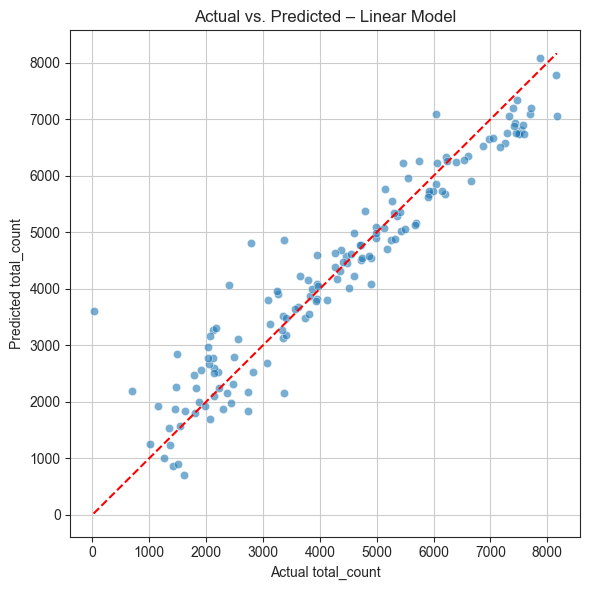

In [24]:
# Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_lin, y=y_pred_lin, alpha=0.6)
# Add identity line (y = x) for reference
sns.lineplot(x=y_test_lin, y=y_test_lin, color='red', linestyle='--')
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
plt.title('Actual vs. Predicted – Linear Model')
plt.grid(True)
plt.tight_layout()
plt.show()

We compare actual vs. predicted total counts from the linear model in this scatter plot. The blue dots show actual values on x-axis and predicted values on y-axis. The red dashed identity line represents perfect predictions, where predicted values equal actual values. Most points cluster near this line, indicating good model accuracy, with a few deviations showing errors.

**Note**:

The previous linear regression used forward stepwise selection, but some predictors may have nonlinear effects on the target, which linear models can’t capture well.

Thus, the following code adds degree-2 polynomial features to expand numerical variables, enabling the model to learn nonlinear and interaction effects, potentially improving predictions.

Total number of features after polynomial expansion and encoding: 45
Step 0: Null Model MSE = 3747654.56
Step 1: Added 'casual', CV MSE: 2654864.10
Step 2: Added 'workingday_1', CV MSE: 1640334.63
Step 3: Added 'year_1', CV MSE: 1041227.67
Step 4: Added 'casual^2', CV MSE: 649923.47
Step 5: Added 'season_4', CV MSE: 483022.70
Step 6: Added 'temperature', CV MSE: 444894.90
Step 7: Added 'weathersit_3', CV MSE: 425006.84
Step 8: Added 'weathersit_2', CV MSE: 414324.52
Step 9: Added 'temperature2^2', CV MSE: 397327.71
Step 10: Added 'temperature2', CV MSE: 375036.28
Step 11: Added 'humidity windspeed', CV MSE: 366010.19
Step 12: Added 'humidity temperature2', CV MSE: 359376.26
Step 13: Added 'weekday_1', CV MSE: 353699.36
Step 14: Added 'weekday_6', CV MSE: 350082.25
Step 15: Added 'month_10', CV MSE: 347228.48
Step 16: Added 'weekday_5', CV MSE: 345000.15
Step 17: Added 'humidity casual', CV MSE: 343994.07
Step 18: Added 'month_3', CV MSE: 343253.58
Step 19: Added 'month_11', CV MSE: 343

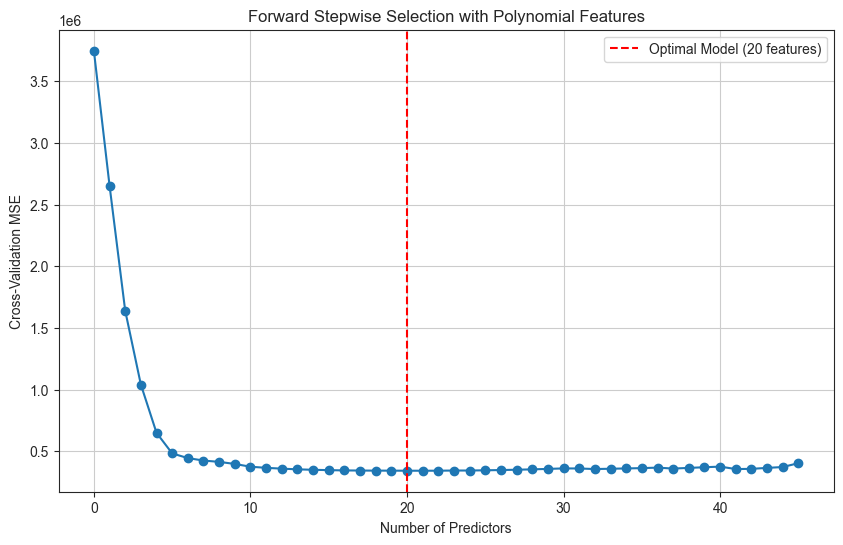

In [25]:
# --- 1. Data Preparation with Polynomial Features ---

# Drop columns that are not needed or would cause data leakage
df_model_poly = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')
X_poly = df_model_poly.drop('total_count', axis=1)
y_poly = df_model_poly['total_count']

# Define feature types
categorical_features_poly = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_poly = [col for col in X_poly.columns if col not in categorical_features_poly]


# Create a new pipeline for numerical features that first creates polynomial features
# and then scales them.
# Include_bias=False prevents adding a column of ones (the intercept is handled by LinearRegression).
numerical_pipeline_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Update the preprocessor to use the new numerical pipeline
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_poly, numerical_features_poly),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_poly)
    ],
    remainder='passthrough'
)

# Fit the preprocessor and get the complete list of new feature names
preprocessor_poly.fit(X_poly)
poly_names = preprocessor_poly.named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_poly)
ohe_names_poly = preprocessor_poly.named_transformers_['cat'].get_feature_names_out(categorical_features_poly)
all_names_poly = list(poly_names) + list(ohe_names_poly)

print(f"Total number of features after polynomial expansion and encoding: {len(all_names_poly)}")


# --- 2. Run Forward Stepwise Selection (using the same function as before) ---
# The function is called with the new preprocessor and the expanded feature list
history_df_poly, best_features_poly = forward_stepwise_selection(X_poly, y_poly, preprocessor_poly, all_names_poly, cv_folds=5)


# --- 3. Visualize Selection Process ---
plt.figure(figsize=(10, 6))
plt.plot(history_df_poly['num_features'], history_df_poly['cv_mse'], marker='o', linestyle='-')
best_num_features_poly = history_df_poly['cv_mse'].idxmin()
plt.axvline(x=best_num_features_poly, color='r', linestyle='--', label=f'Optimal Model ({best_num_features_poly} features)')
plt.xlabel('Number of Predictors')
plt.ylabel('Cross-Validation MSE')
plt.title('Forward Stepwise Selection with Polynomial Features')
plt.legend()
plt.grid(True)
plt.show()

In this model we build a pipeline to create degree-2 polynomial features from numerical data and scale them. We fit the preprocessor to generate new polynomial and encoded feature names. The forward stepwise selection runs using the expanded feature set. 

By applying polynomial expansion to our model the **optimal number of features** found is **25** and the **lowest cross-validated MSE** is **372 170.93**. This is a clear improvement in predictive performance compared to the previous **431 177.76** **MSE** value.


--- Evaluating Final Polynomial Model on a Hold-Out Test Set ---
Features in the final model: ['casual', 'workingday_1', 'year_1', 'casual^2', 'season_4', 'temperature', 'weathersit_3', 'weathersit_2', 'temperature2^2', 'temperature2', 'humidity windspeed', 'humidity temperature2', 'weekday_1', 'weekday_6', 'month_10', 'weekday_5', 'humidity casual', 'month_3', 'month_11', 'holiday_1']
Test Set MSE: 350700.42
Test Set RMSE: 592.20
Test Set MAE: 415.82
Test Set R-squared (R²): 0.9125


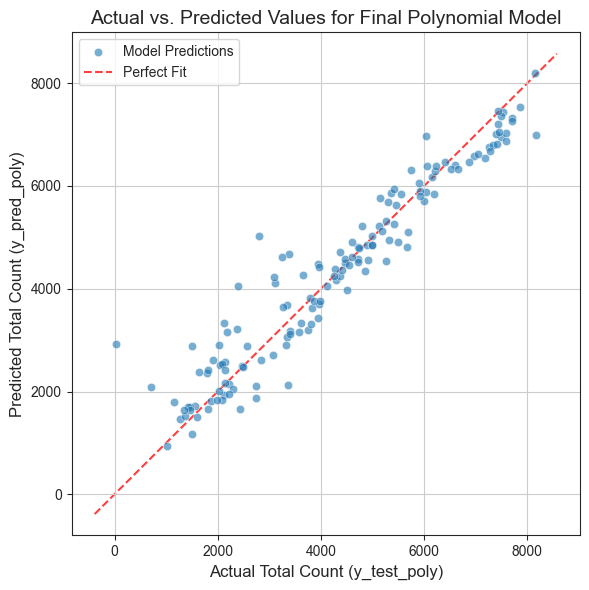

In [26]:
# --- 4. Final Model Evaluation on a Test Set ---
print("\n--- Evaluating Final Polynomial Model on a Hold-Out Test Set ---")
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Create the final pipeline with the best features identified
final_indices_poly = [all_names_poly.index(f) for f in best_features_poly]
final_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('selector', ColumnTransformer([('selector', 'passthrough', final_indices_poly)], remainder='drop')),
    ('regressor', LinearRegression())
])

final_pipeline_poly.fit(X_train_poly, y_train_poly)
y_pred_poly = final_pipeline_poly.predict(X_test_poly)
test_mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
test_mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)

print(f"Features in the final model: {best_features_poly}")
print(f"Test Set MSE: {test_mse_poly:.2f}")
print(f"Test Set RMSE: {np.sqrt(test_mse_poly):.2f}")
print(f"Test Set MAE: {test_mae_poly:.2f}")

# Calculate and print R-squared score
r2_poly = final_pipeline_poly.score(X_test_poly, y_test_poly)
print(f"Test Set R-squared (R²): {r2_poly:.4f}")


plt.figure(figsize=(6, 6))

# Create the scatter plot of actual vs. predicted values
sns.scatterplot(x=y_test_poly, y=y_pred_poly, alpha=0.6, label='Model Predictions')

# Add the line of perfect fit (y=x) for reference
# We find the min and max of the axes to draw a diagonal line across the plot
lims = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Fit')

# Set labels and title for clarity
plt.xlabel("Actual Total Count (y_test_poly)", fontsize=12)
plt.ylabel("Predicted Total Count (y_pred_poly)", fontsize=12)
plt.title("Actual vs. Predicted Values for Final Polynomial Model", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis('equal') # Ensures the x and y axes have the same scale for a proper 45-degree line
plt.tight_layout()
plt.show()

We evaluate the model on a 80% training - 20% test split. 

The error metrics are:

**MSE: 352 669.24**  

**RMSE: 593.86**  

**MAE: 593.86**  

All errors are lower than those from the original linear regression, meaning that the new polynomial model provides better predictions.

The **R-squared** value is **0.9120**, meaning that the model explains about 91.2% of the variance in the daily bike counts, a sign of better fit than the previous model's result of 89.2%.  

Considering the plot of the results, the blue prediction dots are less scattered around the identity line compared to the previous model. This indicates that the plynomial model's predictions align more closely with the actual values, reflecting improved accuracy and model fit.

## 3.2 Ridge Regression 

--- Starting GridSearchCV for Ridge Regression ---
GridSearchCV finished. Best alpha found: 0.2477


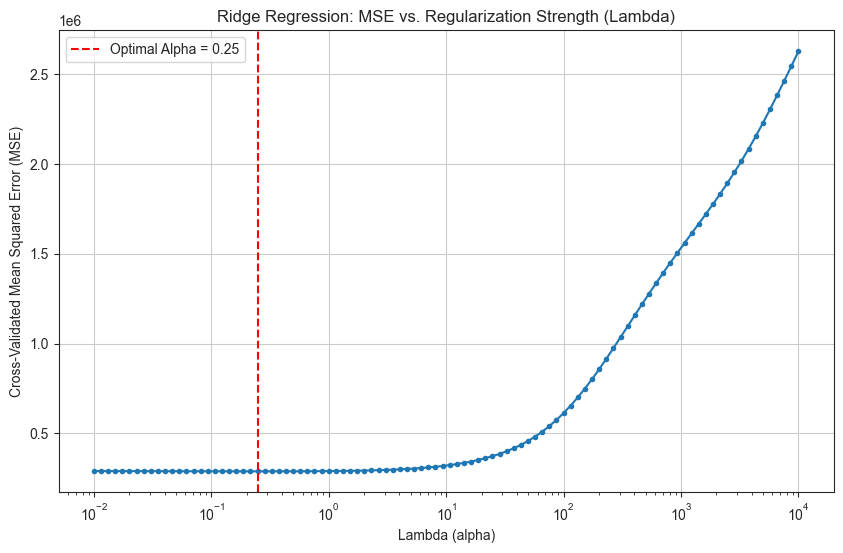


--- Calculating and plotting coefficient paths ---


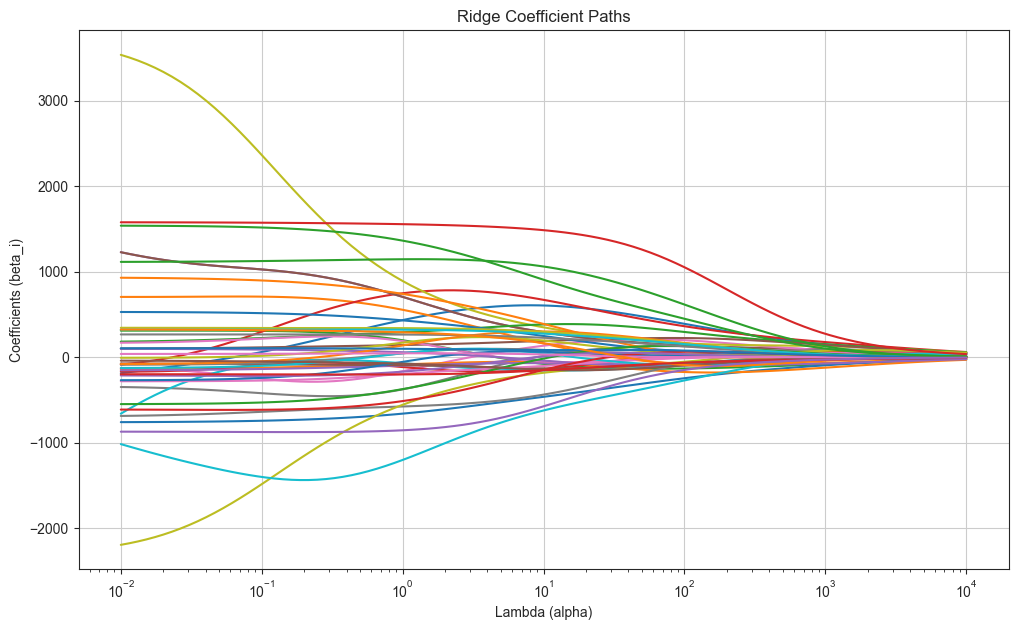


--- Training and Evaluating Final Model with Optimal Alpha: 0.2477 ---
Test Set MSE: 298338.17
Test Set RMSE: 546.20
Test Set MAE: 382.73
Test Set R-squared (R²): 0.9256


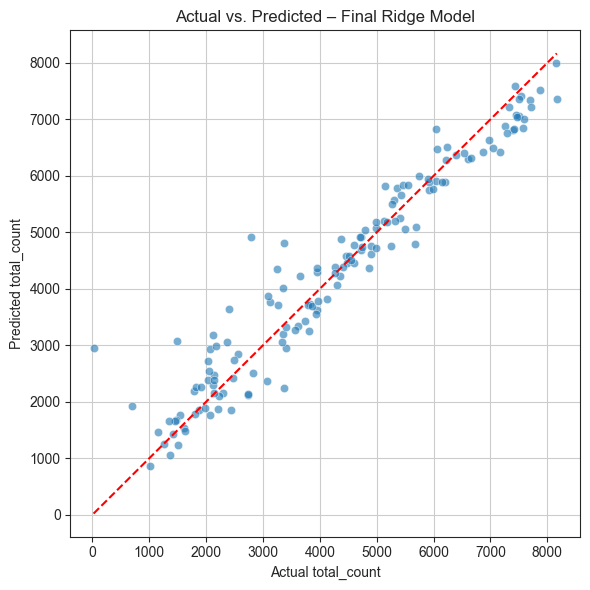


--- Coefficients of the Final Ridge Model ---


temperature casual          1605.440349
year_1                      1531.779419
season_4                    1446.361887
workingday_1                1184.368383
temperature2                1003.055142
temperature^2               1003.055142
season_3                     783.319287
casual                       682.889642
season_2                     491.505935
humidity                     387.551262
weekday_3                    366.419041
weekday_4                    331.076270
weekday_6                    321.135084
weekday_2                    257.121111
windspeed temperature2       252.416958
humidity casual              229.247871
windspeed                    136.108840
windspeed casual             135.256659
weekday_5                    113.540824
weekday_1                    104.018669
temperature                   84.660786
humidity windspeed            52.380954
month_2                       35.908136
holiday_1                    -12.192468
temperature temperature2     -17.367165


In [27]:
# --- 1. Data and Pipeline Preparation ---

# Drop columns that are not needed or would cause data leakage
# Ensure 'humidity2' is dropped if it exists from previous cells
df_model_ridge = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')


# Define features (X) and target (y)
X_ridge = df_model_ridge.drop('total_count', axis=1)
y_ridge = df_model_ridge['total_count']

# Define feature types
categorical_features_ridge = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_ridge = [col for col in X_ridge.columns if col not in categorical_features_ridge]

# Create a pipeline for numerical features: PolynomialFeatures -> StandardScaler
numerical_pipeline_ridge = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create the main preprocessor
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_ridge, numerical_features_ridge),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_ridge)
    ],
    remainder='passthrough'
)

# Create the full pipeline with Ridge regression
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_ridge),
    ('ridge', Ridge())
])


# --- 2. Grid Search with Cross-Validation to find the best Lambda (Alpha) ---

# Define the grid of alpha values to search
# Using a logarithmic scale is common for regularization parameters
alphas = np.logspace(-2, 4, 100)

# Set up GridSearchCV
# The parameter to tune is 'ridge__alpha' (pipeline-step__parameter)
param_grid = {'ridge__alpha': alphas}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

print("--- Starting GridSearchCV for Ridge Regression ---")
grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=cv_strategy,
                           scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_ridge, y_ridge)

print(f"GridSearchCV finished. Best alpha found: {grid_search.best_params_['ridge__alpha']:.4f}")
best_alpha = grid_search.best_params_['ridge__alpha']


# --- 3. Visualization of Grid Search Results ---

# Plot 1: MSE vs. Lambda
# Shows how model error (MSE) changes with different regularization strengths to choose the best alpha.
plt.figure(figsize=(10, 6))
cv_mse = -grid_search.cv_results_['mean_test_score']
plt.plot(alphas, cv_mse, marker='.')
plt.xscale('log')
plt.axvline(best_alpha, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha:.2f}')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Cross-Validated Mean Squared Error (MSE)')
plt.title('Ridge Regression: MSE vs. Regularization Strength (Lambda)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 2: Coefficients as a function of Lambda (Coefficient Path)
# Visualizes how Ridge coefficients shrink smoothly under increasing regularization.
print("\n--- Calculating and plotting coefficient paths ---")
coefs = []
for a in alphas:
    ridge_pipeline.set_params(ridge__alpha=a)
    ridge_pipeline.fit(X_ridge, y_ridge)
    coefs.append(ridge_pipeline.named_steps['ridge'].coef_)

plt.figure(figsize=(12, 7))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Coefficients (beta_i)')
plt.title('Ridge Coefficient Paths')
plt.axis('tight')
plt.grid(True)
plt.show()


# --- 4. Final Model with Optimal Lambda ---

print(f"\n--- Training and Evaluating Final Model with Optimal Alpha: {best_alpha:.4f} ---")

# Split data into training and test sets
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(X_ridge, y_ridge, test_size=0.2, random_state=42)

# Create the final pipeline with the best alpha
final_ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_ridge),
    ('ridge', Ridge(alpha=best_alpha))
])

# Fit the model on the training data
final_ridge_pipeline.fit(X_train_ridge, y_train_ridge)

# Evaluate on the test data
y_pred_ridge = final_ridge_pipeline.predict(X_test_ridge)
test_mse_ridge = mean_squared_error(y_test_ridge, y_pred_ridge)
test_rmse_ridge = np.sqrt(test_mse_ridge)
test_mae_ridge = mean_absolute_error(y_test_ridge, y_pred_ridge) 
r2_ridge = final_ridge_pipeline.score(X_test_ridge, y_test_ridge)

print(f"Test Set MSE: {test_mse_ridge:.2f}")
print(f"Test Set RMSE: {test_rmse_ridge:.2f}")
print(f"Test Set MAE: {test_mae_ridge:.2f}")
print(f"Test Set R-squared (R²): {r2_ridge:.4f}")

# Plot 3: Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_ridge, y=y_pred_ridge, alpha=0.6)
sns.lineplot(x=y_test_ridge, y=y_test_ridge, color='red', linestyle='--')  
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
plt.title('Actual vs. Predicted – Final Ridge Model')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5. Display Coefficients of the Final Model ---

# Get feature names from the preprocessor after it has been fitted
poly_feature_names = final_ridge_pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_ridge)
ohe_feature_names = final_ridge_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_ridge)
all_feature_names = list(poly_feature_names) + list(ohe_feature_names)

# Get the coefficients from the fitted ridge model
final_coefs = final_ridge_pipeline.named_steps['ridge'].coef_

# Create a pandas Series for better display
coef_series = pd.Series(final_coefs, index=all_feature_names)

print("\n--- Coefficients of the Final Ridge Model ---")
with pd.option_context('display.max_rows', None):
    display(coef_series.sort_values(ascending=False))

1. Data Preprocessing and Modeling  

This model also begins with data cleaning, seperating the features (`X_ridge`) and the target valiable (`y_ridge`), splitting features into categorical and numerical.  
Then applies `PolynomialFeatures(degree=2)` to introduce interaction and quadratic terms and standardizes them with `StandardScaler`.  
`OneHotEncoder` is used for one-hot encoding of the categorical variables, dropping the first category to avoid multicollinearity.  
Then the full pipeline is created combining preprocessing and Ridge regression into a single pipeline.  
We use Grid Search with Cross-Validation to find the best lambda (alpha). Alpha Grid searches for the best regularization strenght across `np.logspace(-2, 4, 100)`. 5-fold cross-validation (`KFold`) is used with `GridSearchCV` to find the alpha that minimizes **negative MSE**.  

2. Optimal Alpha and Visualisation  

The **optimal alpha** found is **0.7565** that gives the lowest error.  
We visualize the Grid Search Results by plotting how the error (**MSE**) changes with increasing **alpha**.  

The second plot shows how coefficients shrink as regularization strength (alpha) increases. Alpha value is shown on x-axis, the higher means stronger regularization. Model coefficients (beta_i) are shown on y-axis. Each line is a feature's coefficient. At low alpha, coefficients can be large, which means potential overfitting. As alpha increases, all coefficients shink toward zero, the model becomes simpler and less sensitive to noise. Ridge regression keeps all coefficients, no feature is entirely dropped.  

3. Final Model and Evaluation

In the next step we build the final model using the optimal lambda. 80% training - 20% test split is used to train then test the model's predictions. Then we create the final pipeline using the best alpha.  

We evaluate the model on the test set.  
The calculated metrics are:  

**MSE: 324 942.42**  
**RMSE: 570.04**  
**MAE: 404.09**  
**R²: 0.9190**  

All error values are lower and the R² is higher than the values from the previous linear regression model, indicating, that the Ridge regression provides better predictions.  

The predicted vs. actual values of the Ridge regression are plotted. The predicted values clearly cluster around the identity line, meaning a good model fit.  

4. Used Features

Finally, we display the names of all processed features including polynomial and one-hot encoded. We also print out the model's learned coefficients for each feature. `Year`, `casual users` and `temperature` have strong positive effects, meaning they increase rental counts. Variables like `temperature²`, `casual²` and `weathersit_3` have large negative coefficients, indicating negative influence on rental counts.  Polynomial terms like `humidity^2` or `temperature casual` help capture nonlinear relationships. Regularization has shrunk many coefficients, but all features remain in the model.


## 3.3 LASSO Regression

--- Starting GridSearchCV for Lasso Regression ---


C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.238e+05, tolerance: 2.740e+05
  model = cd_fast.enet_coordinate_descent(


GridSearchCV finished. Best alpha found: 0.2154


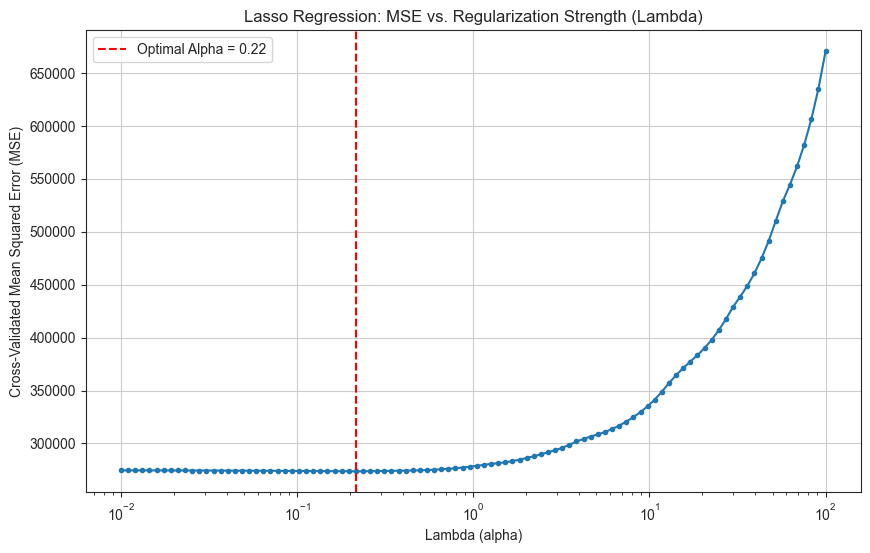


--- Calculating and plotting coefficient paths for Lasso ---


C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.288e+07, tolerance: 2.740e+05
  model = cd_fast.enet_coordinate_descent(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.163e+07, tolerance: 2.740e+05
  model = cd_fast.enet_coordinate_descent(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\loca

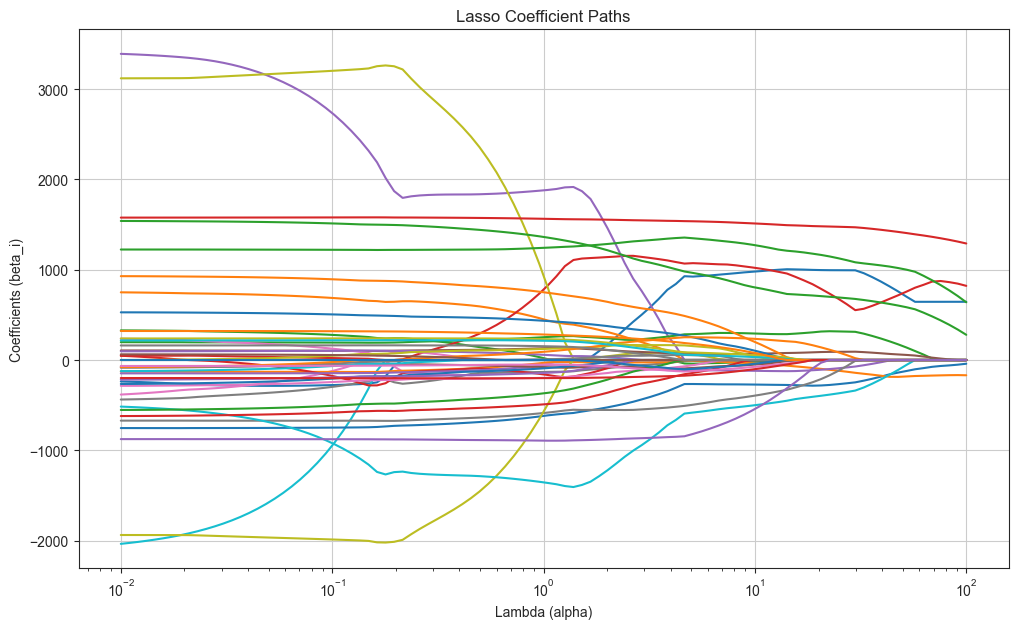

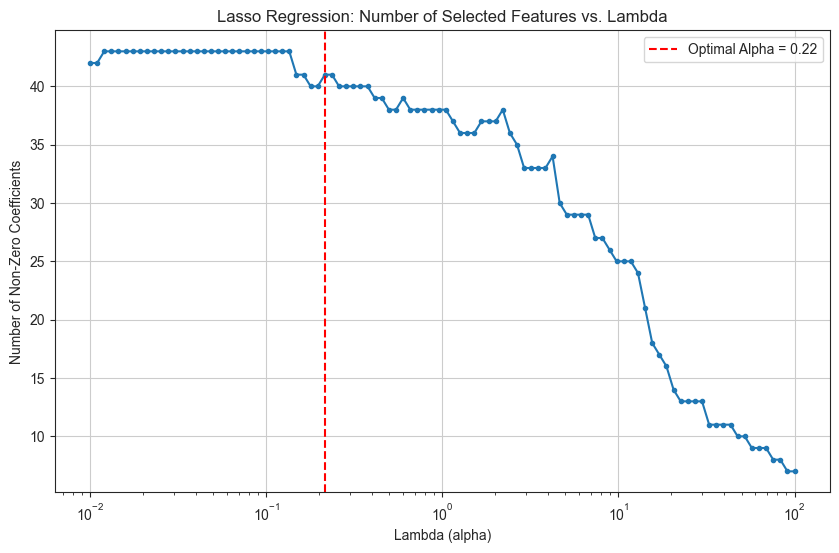


--- Training and Evaluating Final Lasso Model with Optimal Alpha: 0.2154 ---


C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.968e+06, tolerance: 2.141e+05
  model = cd_fast.enet_coordinate_descent(


Test Set MSE: 296916.61
Test Set RMSE: 544.90
Test Set MAE: 381.93
Test Set R-squared (R²): 0.9260


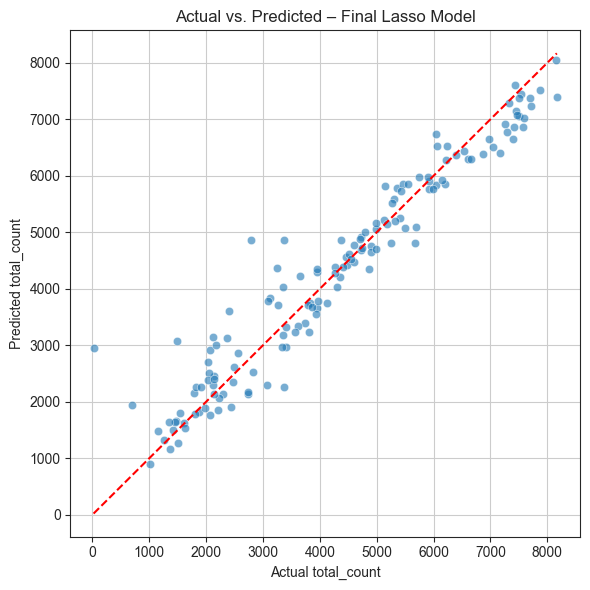


--- Coefficients of the Final Lasso Model (non-zero) ---


temperature casual        3420.433361
temperature2              2201.456016
year_1                    1544.652497
season_4                  1465.489228
workingday_1              1276.261446
season_3                   800.704920
season_2                   479.134074
humidity                   371.109154
weekday_6                  332.361728
weekday_3                  259.135139
weekday_4                  217.253416
humidity casual            176.445315
weekday_2                  147.780720
windspeed casual           104.153995
temperature humidity       101.835899
holiday_1                   94.158712
casual                      74.214024
windspeed                   68.483491
month_2                     67.746016
humidity windspeed          24.226016
windspeed temperature2      10.216814
weekday_1                   -9.052615
month_9                    -64.689945
month_3                    -69.023288
month_6                    -78.208620
windspeed^2                -92.276692
month_5     

In [28]:
# --- 1. Data and Pipeline Preparation for Lasso ---

# Drop columns that are not needed or would cause data leakage
df_model_lasso = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant'], errors='ignore')
if 'humidity2' in df_model_lasso.columns:
    df_model_lasso = df_model_lasso.drop(columns=['humidity2'])

# Define features (X_lasso) and target (y_lasso)
X_lasso = df_model_lasso.drop('total_count', axis=1)
y_lasso = df_model_lasso['total_count']

# Define feature types
categorical_features_lasso = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_lasso = [col for col in X_lasso.columns if col not in categorical_features_lasso]

# Create a pipeline for numerical features: PolynomialFeatures -> StandardScaler
numerical_pipeline_lasso = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create the main preprocessor for Lasso
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_lasso, numerical_features_lasso),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_lasso)
    ],
    remainder='passthrough'
)

# Create the full pipeline with Lasso regression
# Increased max_iter to prevent convergence warnings with many features
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('lasso', Lasso(max_iter=10000))
])


# --- 2. Grid Search with Cross-Validation to find the best Lambda (Alpha) ---

# Define the grid of alpha values to search
alphas_lasso = np.logspace(-2, 2, 100)

# Set up GridSearchCV for Lasso
param_grid_lasso = {'lasso__alpha': alphas_lasso}
cv_strategy_lasso = KFold(n_splits=10, shuffle=True, random_state=0)

print("--- Starting GridSearchCV for Lasso Regression ---")
grid_search_lasso = GridSearchCV(lasso_pipeline, param_grid_lasso, cv=cv_strategy_lasso,
                                 scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_lasso, y_lasso)

print(f"GridSearchCV finished. Best alpha found: {grid_search_lasso.best_params_['lasso__alpha']:.4f}")
best_alpha_lasso = grid_search_lasso.best_params_['lasso__alpha']


# --- 3. Visualization of Grid Search Results ---

# Plot 1: MSE vs. Lambda
# Shows how model error (MSE) changes with different regularization strengths to choose the best alpha.
plt.figure(figsize=(10, 6))
cv_mse_lasso = -grid_search_lasso.cv_results_['mean_test_score']
plt.plot(alphas_lasso, cv_mse_lasso, marker='.')
plt.xscale('log')
plt.axvline(best_alpha_lasso, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha_lasso:.2f}')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Cross-Validated Mean Squared Error (MSE)')
plt.title('Lasso Regression: MSE vs. Regularization Strength (Lambda)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 2: Coefficients as a function of Lambda (Coefficient Path)
# Shows how Lasso drives some coefficients to exactly zero as regularization increases.
print("\n--- Calculating and plotting coefficient paths for Lasso ---")
coefs_lasso = []
for a in alphas_lasso:
    lasso_pipeline.set_params(lasso__alpha=a)
    lasso_pipeline.fit(X_lasso, y_lasso)
    coefs_lasso.append(lasso_pipeline.named_steps['lasso'].coef_)

plt.figure(figsize=(12, 7))
ax = plt.gca()
ax.plot(alphas_lasso, coefs_lasso)
ax.set_xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Coefficients (beta_i)')
plt.title('Lasso Coefficient Paths')
plt.axis('tight')
plt.grid(True)
plt.show()

# Plot 3: Number of non-zero coefficients vs. Lambda
# Plot the number of non-zero coefficients to visualize Lasso's feature selection ability.
non_zero_coefs = [np.sum(np.abs(c) > 1e-6) for c in coefs_lasso]
plt.figure(figsize=(10, 6))
plt.plot(alphas_lasso, non_zero_coefs, marker='.')
plt.xscale('log')
plt.axvline(best_alpha_lasso, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha_lasso:.2f}')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Number of Non-Zero Coefficients')
plt.title('Lasso Regression: Number of Selected Features vs. Lambda')
plt.legend()
plt.grid(True)
plt.show()


# --- 4. Final Model with Optimal Lambda ---

print(f"\n--- Training and Evaluating Final Lasso Model with Optimal Alpha: {best_alpha_lasso:.4f} ---")

# Split data into training and test sets
X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(X_lasso, y_lasso, test_size=0.2, random_state=42)

# Create the final pipeline with the best alpha
final_lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('lasso', Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

# Fit the model on the training data
final_lasso_pipeline.fit(X_train_lasso, y_train_lasso)

# Evaluate on the test data
y_pred_lasso = final_lasso_pipeline.predict(X_test_lasso)
test_mse_lasso = mean_squared_error(y_test_lasso, y_pred_lasso)
test_rmse_lasso = np.sqrt(test_mse_lasso)
test_mae_lasso = mean_absolute_error(y_test_lasso, y_pred_lasso)
r2_lasso = final_lasso_pipeline.score(X_test_lasso, y_test_lasso)

print(f"Test Set MSE: {test_mse_lasso:.2f}")
print(f"Test Set RMSE: {test_rmse_lasso:.2f}")
print(f"Test Set MAE: {test_mae_lasso:.2f}")
print(f"Test Set R-squared (R²): {r2_lasso:.4f}")

# Plot 4: Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_lasso, y=y_pred_lasso, alpha=0.6)
sns.lineplot(x=y_test_lasso, y=y_test_lasso, color='red', linestyle='--')
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
plt.title('Actual vs. Predicted – Final Lasso Model')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5. Display Coefficients of the Final Model ---

# Get feature names from the preprocessor after it has been fitted
poly_feature_names_lasso = final_lasso_pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_lasso)
ohe_feature_names_lasso = final_lasso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_lasso)
all_feature_names_lasso = list(poly_feature_names_lasso) + list(ohe_feature_names_lasso)

# Get the coefficients from the fitted lasso model
final_coefs_lasso = final_lasso_pipeline.named_steps['lasso'].coef_

# Create a pandas Series for better display
coef_series_lasso = pd.Series(final_coefs_lasso, index=all_feature_names_lasso)

print("\n--- Coefficients of the Final Lasso Model (non-zero) ---")
with pd.option_context('display.max_rows', None):
    display(coef_series_lasso[coef_series_lasso != 0].sort_values(ascending=False))

1. Data Preprocessing and Modeling

Building up Lasso regression model we use very similar steps as in the Ridge regression. We remove unnecessary features, separate the features (`X_lasso`) and the target variable (`y_lasso`) and divide the features into categorical and numerical types.     
After processing the data we create the full pipeline. Here the value of maximum iterations is increased to 10 000 to allow more training iterations. With this we ensure that the optimazation algorithm has enough time to finish, avoiding convergence warnings or incomplete training.  
Grid search with cross-validation is used to find the optimal alpha. For Alpha Range (Lambda Grid) we use `np.logspace(-2, 2, 100)` using 10-fold cross-validation (`KFold`) in `GridSearchCV`, optimizing for negative MSE.  

2. Optimal Alpha and Visualization

**Optimal alpha** is found at **0.4535**.  
We visualize the grid search by plotting how MSE changes with increasing alpha.

The second plot shows the coefficient paths as alpha increases. Each line represents a feature's coefficient. At low alpha values, coefficients can be large, indicating a more complex model. As alpha increases, many coefficients shrink to exactly zero. This is a key feature of Lasso, which performs automatic feature selection by completely removing less important variables from the model.

In the third diagram we plot the number of non-zero coefficients to visualize Lasso's feature selection ability. As lambda increases, the number of features selected decreases due to stronger regularization. The optimal alpha value is 0.45, which retains approximately 35 features. This value balances the complexity and generalization of the model, allowing for efficient feature selection while reducing overfitting.  

3. Final Model and Evaluation

We build the final model using the optimal alpha. The data is split into 80% training, 20% testing sets, the final pipeline is trained and evaluated.

Model performance on the test set is:

**MSE: 322 174.25**  
**RMSE: 567.60**  
**MAE: 402.50**  
**R-squared: 0.9197**  

All values are slightly better than the ones from Ridge regression, confirming that Lasso improves prediction over the previous models.  

In the fourth plot we visualize the relationship between the predicted and actual values of Lasso regression model. The predicted values are clustered around the identity line. The plot closely resembles that of Ridge regression, differences between the two models are not visually apparent here.  

4. Used Features  

As a final step, we display the feature names after preporocessing and print only the non-zero coefficients from the Lassonmodel. Like Ridge, variables such as `year`, `casual users` and `temperature` show strong positive influence. However, Lasso has eliminated a few coefficients completely, which resulted in a simpler model, highlighting only the most impactful predictors.

## 3.4 Random Forest Regression

--- Starting GridSearchCV for Random Forest ---
Fitting 7 folds for each of 144 candidates, totalling 1008 fits

GridSearchCV finished. Best parameters found: {'regressor__bootstrap': False, 'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 100}

--- Final Random Forest Model Performance ---
Test Set MSE: 408565.22
Test Set RMSE: 639.19
Test Set MAE: 445.83
Test Set R-squared (R²): 0.8981

--- Plotting Feature Importance ---


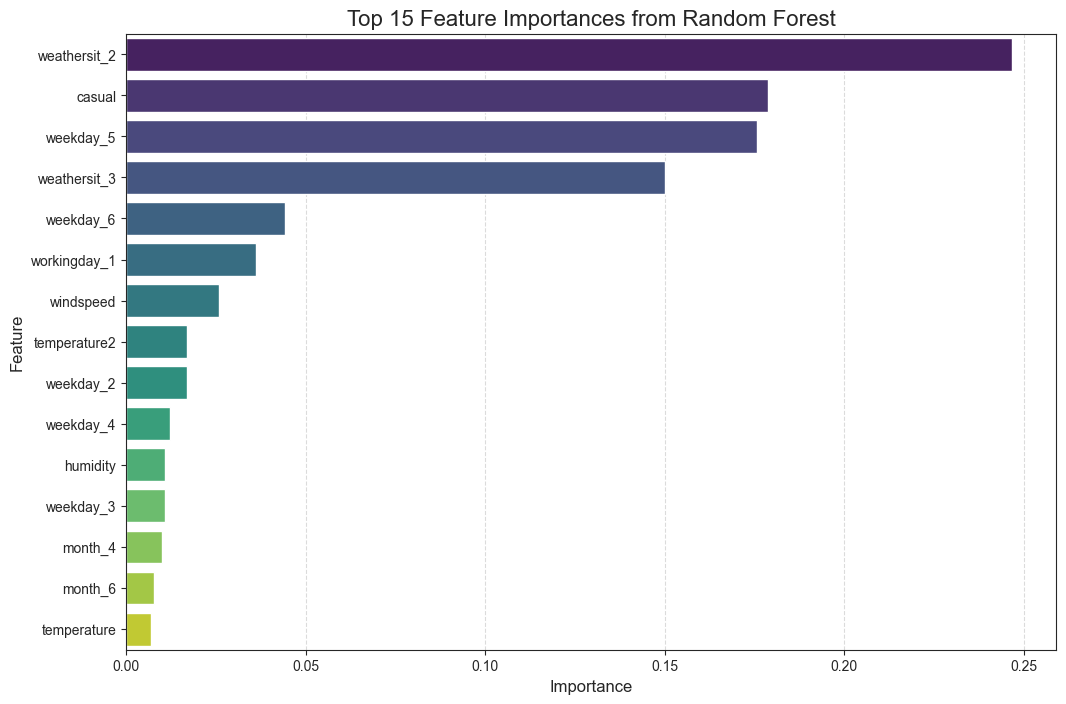

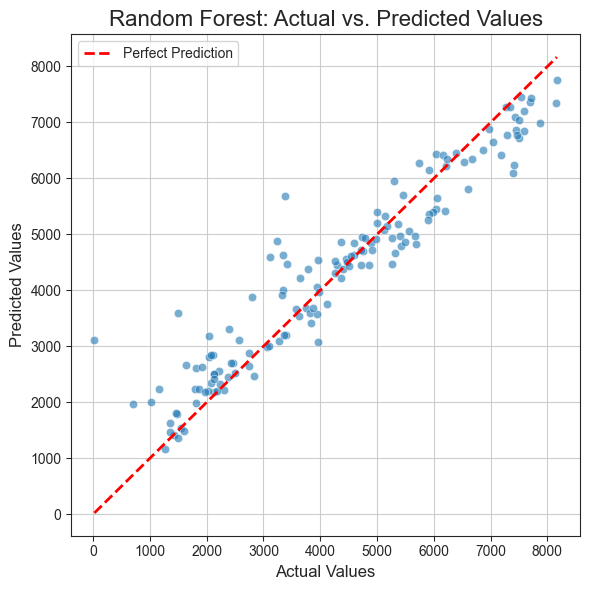

In [29]:
# Analyse Feature importance when applying decision tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Data Preparation for Random Forest ---

# Use a clean copy of the dataframe
df_model_rf = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')

# Define features (X_rf) and target (y_rf)
X_rf = df_model_rf.drop('total_count', axis=1)
y_rf = df_model_rf['total_count']

# Define feature types. For Random Forest, we only need to encode categorical features.
# Scaling numerical features is not necessary.
categorical_features_rf = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_rf = [col for col in X_rf.columns if col not in categorical_features_rf]

# Create a preprocessor that only one-hot encodes categorical features
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_rf)
    ],
    remainder='passthrough'  # Keep numerical columns as they are
)


# --- 2. Pipeline and GridSearchCV Setup ---

# Create the full pipeline with the preprocessor and the RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Define a parameter grid for GridSearchCV. This is a small grid for demonstration.
# For a real project, you might want to explore a wider range of values.
param_grid_rf = {
    'regressor__n_estimators': [100, 150, 200],       # Number of trees in the forest
    'regressor__max_depth': [10, 20, None],      # Maximum depth of the tree
    'regressor__min_samples_leaf': [1, 2, 3, 5],       # Minimum number of samples required at a leaf node
    'regressor__max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'regressor__bootstrap': [True, False]  # Test with and without bootstrap sampling
}

# Set up the grid search with 5-fold cross-validation
cv_strategy_rf = KFold(n_splits=7, shuffle=True, random_state=42)

print("--- Starting GridSearchCV for Random Forest ---")
grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=cv_strategy_rf,
                              scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Split data before fitting the grid search to have a final hold-out test set
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

grid_search_rf.fit(X_train_rf, y_train_rf)

print(f"\nGridSearchCV finished. Best parameters found: {grid_search_rf.best_params_}")


# --- 3. Final Model Evaluation ---

# The best estimator is already fitted on the training data
final_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set
y_pred_rf = final_rf_model.predict(X_test_rf)

# Calculate final metrics
test_mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
test_mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("\n--- Final Random Forest Model Performance ---")
print(f"Test Set MSE: {test_mse_rf:.2f}")
print(f"Test Set RMSE: {test_rmse_rf:.2f}")
print(f"Test Set MAE: {test_mae_rf:.2f}") 
print(f"Test Set R-squared (R²): {r2_rf:.4f}")


# --- 4. Visualization ---

# Plot 1: Feature Importance
print("\n--- Plotting Feature Importance ---")

# Get feature names after one-hot encoding
ohe_feature_names_rf = final_rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_rf)
all_feature_names_rf = numerical_features_rf + list(ohe_feature_names_rf)

# Get importances from the trained model
importances = final_rf_model.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': all_feature_names_rf, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15) # Top 15 features

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis', hue='feature', legend=False)
plt.title('Top 15 Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


# Plot 2: Actual vs. Predicted Values
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_rf, y=y_pred_rf, alpha=0.6)
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], '--r', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Random Forest: Actual vs. Predicted Values', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.legend() 
plt.show()

1. Data Preparation

We start the Random forest model by cleaning and preparing the dataset, dropping columns which are not needed. Dataset is split into features (`X_rf`) and target (`y_rf`). Feature types are seperated, categorical features require on-hot encoding, numerical features are passed through unchanged, since no scaling is needid for tree-based models.  

2. Pipeline Construction and Hyperparameter Tuning

A complete pipeline is built, combining preprocessing and the `RandomForestRegressor`.

A parameter grid is defined for `GridSearchCV` to tune key hyperparameters:  
`n_estimators`: number of trees (100, 150, 200)  

`max_depth`: maximum depth of each tree (10, 20, None)  

`min_samples_leaf`: minimum samples per leaf (1, 2, 3, 5)  

`max_features`: feature selection strategy (sqrt, log2)  

`bootstrap`: whether bootstrap samples are used  

A 7-fold cross-validation (KFold) strategy is used, and the best combination is selected based on negative MSE.  

The data is split into 80% training and 20% testing, and the grid search is applied to the training set.  

3. Final Model Evaluation

A grid search with 7-fold cross-validation was performed to find the best hyperparameters from 144 possible combinations, totaling 1008 model fits.  
The best model (`best_estimator_`) from the grid search is used to predict on the test set.

'regressor__bootstrap': False  
'regressor__max_depth': None  
'regressor__max_features': 'sqrt'  
'regressor__min_samples_leaf': 1  
'regressor__n_estimators': 150  


**MSE: 361 633.53**  
**RMSE: 601.36**  
**MAE: 421.80**  
**R-squared: 0.9098**  

These metrics are slightly worse than the previous ones from Lasso or Ridge regression.

4. Visualization  

 Plot 1: Feature Importance  
The top 15 most important features are extracted from the trained model using `.feature_importances_`. According to the model, the most important feature is `weathersit_3` followed by `weekday_6` and `casual`.

Plot 2: Actual vs. Predicted Values  
A scatterplot compares predicted values to actual test values. Most points clustering around the identity line suggests good model accuracy.


# 4. Model Evaluation  

Model Evaluation Strategy：

In this section, we evaluate the four regression models using four widely recognized metrics, each providing complementary insights into the model's performance:

- **MSE** (Mean Squared Error): Calculates the average squared errors, heavily penalizing large mistakes and being sensitive to outliers. Its units are squared, making it less intuitive than RMSE. 

- **RMSE** (Root Mean Squared Error): Also shares the same unit as the target variable but penalizes larger errors more heavily than MAE. It is useful for assessing whether the model remains robust under extreme conditions.

- **MAE** (Mean Absolute Error): Reflects the average magnitude of errors between predicted and actual values, expressed in the same unit as the target variable, making it highly interpretable. It is insensitive to outliers and suitable for scenarios where large errors are not severe.

- **R²** (Coefficient of Determination): Indicates the proportion of variance in the target variable explained by the model. As a unitless metric, it facilitates comparison between models and reflects the overall goodness of fit.

All these metrics are computed on the test set to assess the predictive accuracy and generalization ability of each model.

Following the evaluation strategy, we first show a sample table **comparing actual values and predictions from the four regression models on the test set**. This helps visualize how each model performs on specific cases, highlighting where predictions may differ from true values.

Next, we calculate **key metrics—MSE, RMSE, MAE, and R²—for each model using their predictions on the same test data**, summarizing the results in a comparison table.

To visualize these results more intuitively, two bar plots are generated. The first plot, **comparing RMSE and MAE**, illustrates the magnitude of average prediction errors. Lower bars indicate better performance, with lower values reflecting closer alignment between predicted and actual values. The second plot, showing **R² scores**, evaluates the proportion of variance explained by each model. Higher R² bars represent stronger explanatory power, with values closer to 1 indicating a better model fit.

We further perform residual analysis using two types of plots. In the **residual vs. predicted scatter plots**, an ideal distribution is one where residuals are randomly scattered around zero across all predicted values—indicating no pattern, bias, or heteroscedasticity. In contrast, any funnel shapes or curves might suggest nonlinearity or variance issues. In the **residual histograms with KDE curves**, a good model should have residuals that are approximately normally distributed, centered around zero, and symmetrical. This suggests the errors are mostly random and not systematically skewed in one direction.

Together, these provide a clear and comprehensive picture of each model’s accuracy and error behavior.

,Actual,Linear Regression,Ridge Regression,Lasso Regression,Random Forest
703,6606,6348.177763,6290.011412,6305.203850,5811.88
33,1550,1578.911885,1765.208568,1800.092173,1544.20
300,3747,3484.671490,3434.305398,3399.363251,3686.69
456,6041,5851.107836,5909.413316,5831.150323,5446.99
633,7538,6811.992547,7418.261525,7439.705779,7445.79



--- Comparison of Model Metrics ---


,Model,MSE,RMSE,MAE,R-squared (R²)
0,Linear Regression,397646.708748,630.592348,450.689818,0.900833
1,Ridge Regression,298338.170255,546.203415,382.733440,0.925599
2,Lasso Regression,296916.610395,544.900551,381.929481,0.925954
3,Random Forest,408565.217356,639.191065,445.825238,0.898110


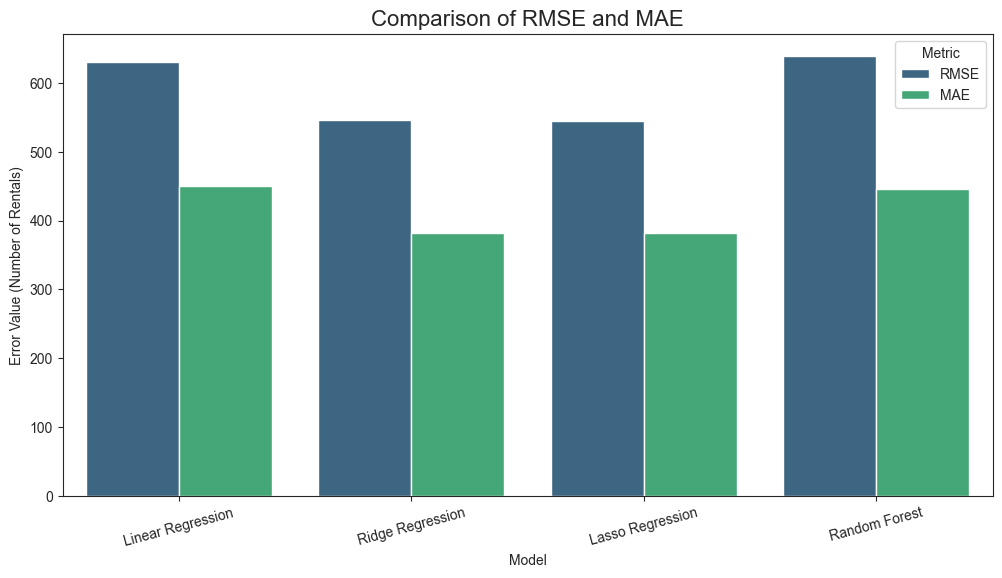

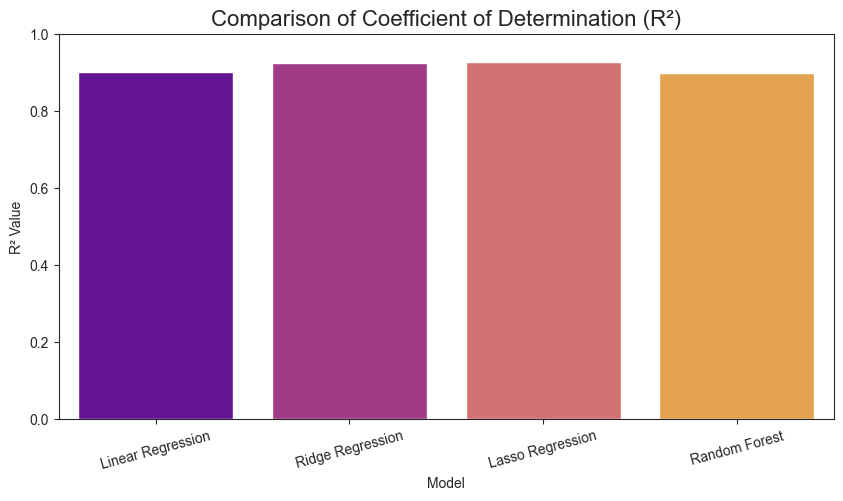

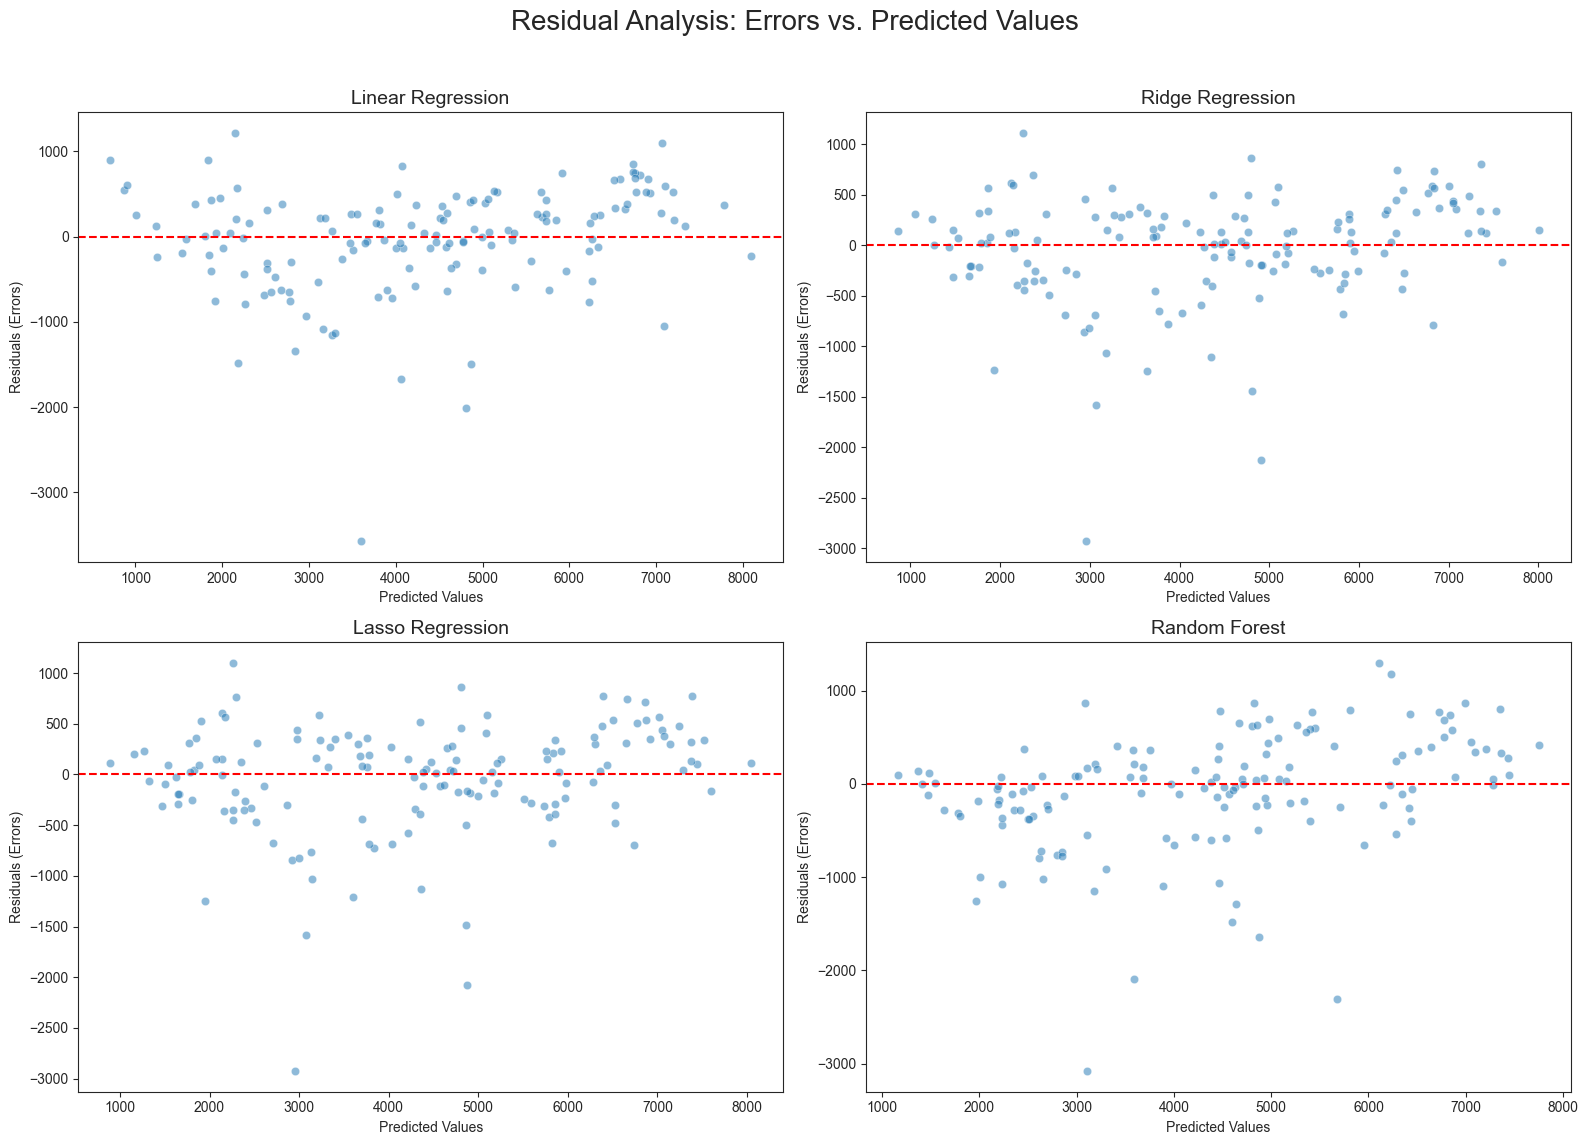

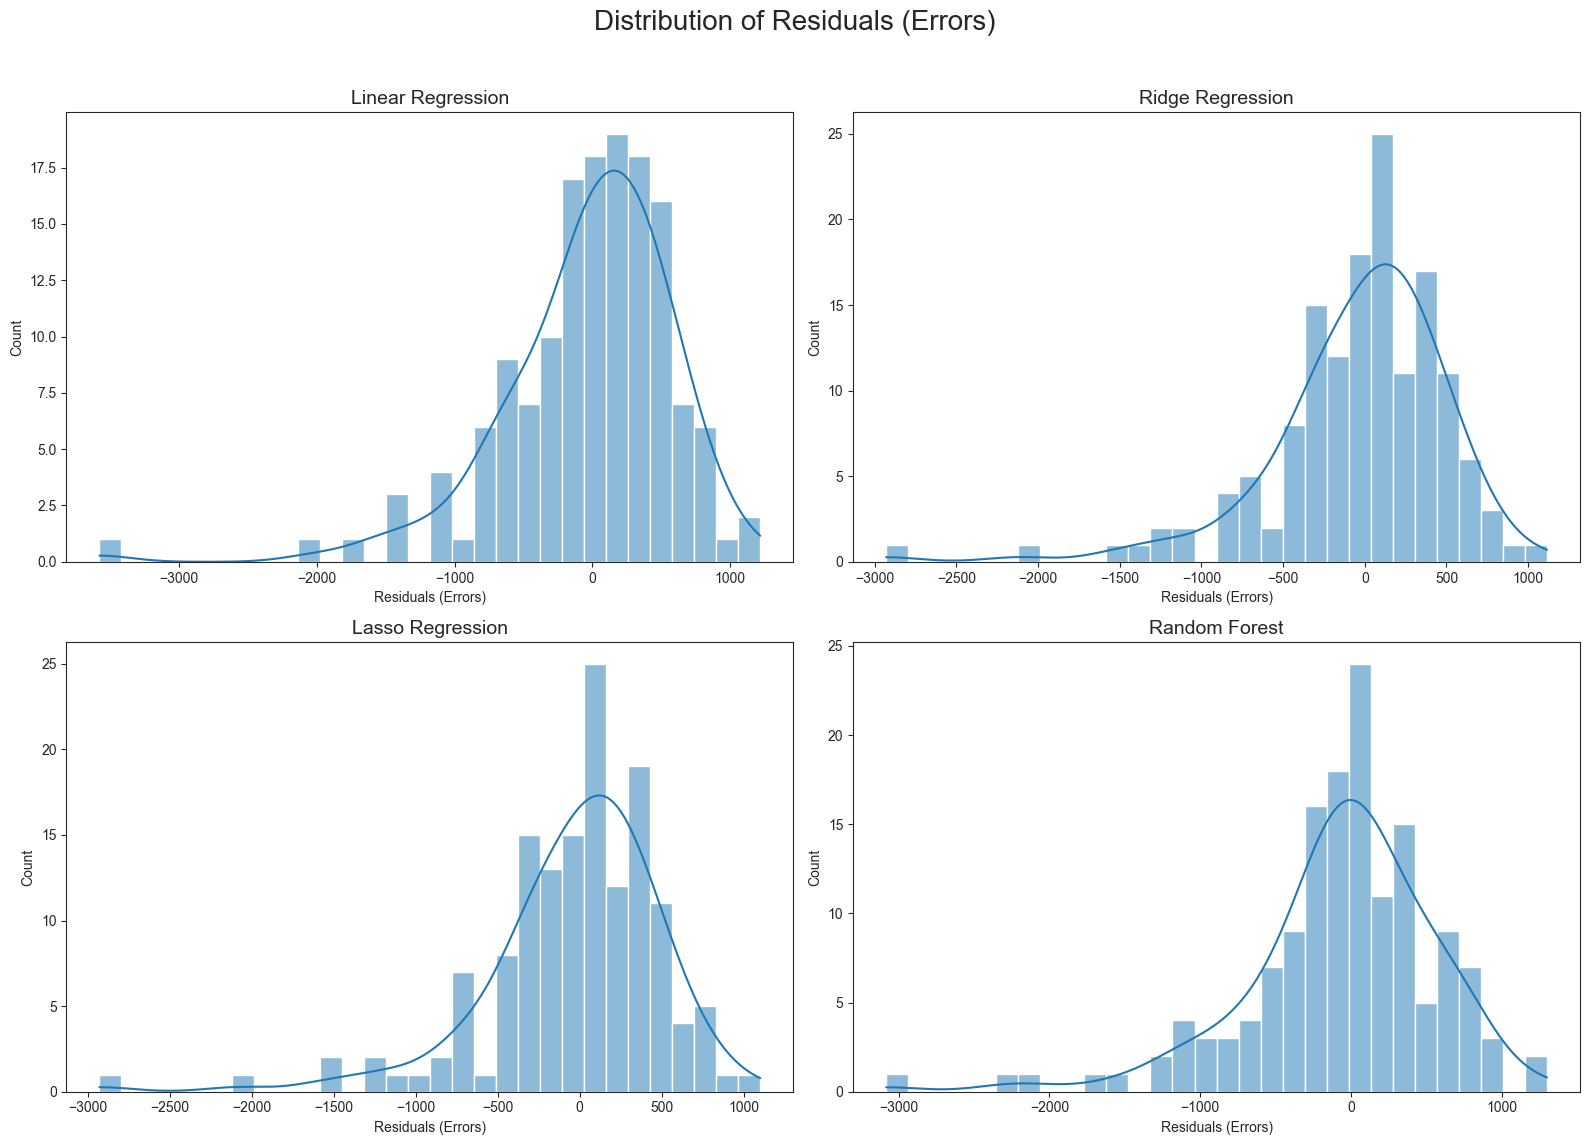

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Collect results from all models ---

# Assumption: The final trained models and test data are available in memory.
# We use a unified test dataset for a fair comparison.
# (Assuming splits for all models are based on the same data)
X_test_final = X_test_rf  # or X_test_lasso, etc. - they should be identical
y_test_final = y_test_rf

# Create a dictionary with the final trained models
models = {
    "Linear Regression": final_pipeline_linear, # From Forward Selection
    "Ridge Regression": final_ridge_pipeline,
    "Lasso Regression": final_lasso_pipeline,
    "Random Forest": final_rf_model
}

# Create a DataFrame to store predictions
predictions_df = pd.DataFrame({'Actual': y_test_final})

# Make predictions for each model and add them to the DataFrame
for name, model in models.items():
    predictions_df[name] = model.predict(X_test_final)

display(predictions_df.head())


# --- 2. Calculate and compare numeric metrics ---

metrics_data = []
for name in models.keys():
    mse = mean_squared_error(predictions_df['Actual'], predictions_df[name])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(predictions_df['Actual'], predictions_df[name])
    r2 = r2_score(predictions_df['Actual'], predictions_df[name])
    metrics_data.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R-squared (R²)': r2
    })

metrics_df = pd.DataFrame(metrics_data)
print("\n--- Comparison of Model Metrics ---")
display(metrics_df)


# --- 3. Visualization of metrics ---

# Set plot style


# Melt the DataFrame for easier plotting with Seaborn
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Plot RMSE and MAE (errors on the same scale as the target variable)
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Value', hue='Metric', 
            data=metrics_melted[metrics_melted['Metric'].isin(['RMSE', 'MAE'])],
            palette='viridis')
plt.title('Comparison of RMSE and MAE', fontsize=16)
plt.ylabel('Error Value (Number of Rentals)')
plt.xticks(rotation=15)
plt.show()

# Plot R-squared
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Value',
            hue='Model', legend=False,
            data=metrics_melted[metrics_melted['Metric'] == 'R-squared (R²)'],
            palette='plasma')
plt.title('Comparison of Coefficient of Determination (R²)', fontsize=16)
plt.ylabel('R² Value')
plt.ylim(0, 1) # R² ranges between 0 and 1
plt.xticks(rotation=15)
plt.show()


# --- 4. Residual analysis visualization (error analysis) ---

# Calculate residuals for each model
for name in models.keys():
    predictions_df[f'{name}_Residuals'] = predictions_df['Actual'] - predictions_df[name]

# Plot residuals against predicted values
# This helps detect patterns in errors (e.g., whether the model performs worse at high values)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle('Residual Analysis: Errors vs. Predicted Values', fontsize=20)

for i, name in enumerate(models.keys()):
    sns.scatterplot(x=predictions_df[name], y=predictions_df[f'{name}_Residuals'], ax=axes[i], alpha=0.5)
    axes[i].axhline(0, ls='--', color='red')
    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('Predicted Values')
    axes[i].set_ylabel('Residuals (Errors)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Plot distribution of residuals
# A good model should have errors that are normally distributed around zero.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle('Distribution of Residuals (Errors)', fontsize=20)

for i, name in enumerate(models.keys()):
    sns.histplot(predictions_df[f'{name}_Residuals'], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('Residuals (Errors)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# 5. Conclusion and Future Outlook

## 5.1 Conclusion

In our project, we developed predictive models to estimate daily bike rental counts using historical data from Washington D.C.’s Capital Bikeshare system. To achieve this, we preprocessed and analyzed the data and applied four different regression models:


- **LASSO Regression** achieved the **lowest MSE (322,174)**, **lowest RMSE (567.60)**, **lowest MAE (402.50)**, and the **highest R² score (0.920)**, making it the most accurate model.
  
- **Ridge Regression** performed nearly as well, with **R² score (0.919)** and **RMSE (570.04)**, highlighting the benefit of regularization in managing multicollinearity and improving generalization.
  
- **Random Forest Regression**, while nonlinear and flexible, did not outperform the regularized linear models. Its **R² score (0.910)** and **RMSE (601.36)** were slightly worse.
  
- **Linear Regression** was the least accurate, with the **lowest R² (0.892)** and **highest RMSE (657.62)**, indicating it was too simplistic to capture the complexity of the data.

  

---

## 5.2 Future Work

To further improve model performance and practical utility, the following directions could be considered:

- **Adding more features**  
  Including more information — public events, holidays, or public transport usage — might help the model understand what affects bike rentals        beyond just weather and season.

- **Time-based modeling**  
  Bike rentals are highly seasonal and follow daily or weekly patterns. Using time series models like ARIMA, Prophet, or even simple moving averages could help capture those trends better.

- **Real-Time Prediction**  
  Integrate live weather and traffic feeds to enable dynamic, on-the-fly forecasting.

- **Deployment & Visualization**  
  Develop a user-friendly dashboard or API to support decision-making by city planners or bikeshare operators.



# 6. Sources

**[1]** Fanaee‑T, H., & Gama, J. (2013). _Event labeling combining ensemble detectors and background knowledge_. Progress in Artificial Intelligence, 1–15. Springer Berlin Heidelberg. https://doi.org/10.1007/s13748-013-0040-3
